In [190]:
import json
import re
import pandas as pd
import ollama

In [95]:
eval_df = pd.read_csv("../data/eval/eval_set.csv")

print(eval_df.shape)
eval_df.head()

(200, 16)


,feedback_id,rating,review_title,review_text,feedback,is_source_artifact,is_low_information,is_usable_feedback,text_for_ai,clean_title,gold_sentiment,gold_intent,gold_product_area,gold_theme,gold_severity,gold_actionability
0,52581,1.0,works for 20 seconds then crashes have to res...,works for 20 seconds then crashes. then you ha...,works for 20 seconds then crashes have to res...,False,False,True,works for 20 seconds then crashes have to res...,works for 20 seconds then crashes have to res...,negative,bug_report,reliability,App crashes repeatedly,high,high
1,33251,5.0,Great,I like this app i like a lot i really really d...,Great. I like this app i like a lot i really r...,False,False,True,Great I like this app i like a lot i really re...,Great,mixed,complaint,features,Annoying questionnaires,medium,high
2,50176,5.0,awesome,Awesome I hope it.will be awesome,awesome. Awesome I hope it.will be awesome,False,False,True,awesome Awesome I hope it.will be awesome,awesome,positive,praise,other,General satisfaction,low,low
3,32077,5.0,Great,Easy to save. Easy to use. Great recipes.,Great. Easy to save. Easy to use. Great recipes.,False,False,True,Great Easy to save. Easy to use. Great recipes.,Great,positive,praise,usability,Easy recipe management,low,medium
4,72436,1.0,Not worth it,Only able to use if you have a paid subscriber...,Not worth it. Only able to use if you have a p...,False,False,True,Not worth it Only able to use if you have a pa...,Not worth it,negative,pricing_feedback,pricing,Paid subscription required,high,high


In [96]:
SENTIMENTS = [
    "positive",
    "negative",
    "neutral",
    "mixed"
]

INTENTS = [
    "bug_report",
    "complaint",
    "praise",
    "feature_request",
    "pricing_feedback",
    "question",
    "other"
]

PRODUCT_AREAS = [
    "reliability",
    "usability",
    "performance",
    "features",
    "pricing",
    "compatibility",
    "account",
    "other"
]

SEVERITIES = [
    "low",
    "medium",
    "high"
]

ACTIONABILITY = [
    "low",
    "medium",
    "high"
]

In [107]:
SYSTEM_PROMPT = """
You are a Voice-of-Customer analysis system.

Analyze exactly one customer review.

You MUST return ONLY one valid JSON object.

The JSON MUST contain ALL 8 fields below:
- sentiment
- intent
- product_area
- theme
- severity
- actionability
- confidence
- evidence

The field "confidence" is REQUIRED.
It MUST always be present.
It MUST be a number between 0 and 1.
Example: 0.92

Allowed values:

sentiment:
positive, negative, neutral, mixed

intent:
bug_report, complaint, praise, feature_request, pricing_feedback, question, other

product_area:
reliability, usability, performance, compatibility, pricing, features, account, other

severity:
low, medium, high

actionability:
low, medium, high

Rules:

1. sentiment describes the overall customer attitude.
2. intent describes why the customer wrote the review.
3. product_area identifies the affected product area.
4. theme is a short description of the main issue or experience.
5. severity describes how serious the issue is.
6. actionability describes whether the company should act on this feedback.
7. confidence is your confidence in the complete classification, from 0 to 1.
8. evidence MUST be copied directly from the customer review.
9. Do not invent evidence.
10. Do not explain your reasoning.
11. Do not use markdown.
12. Do not add extra fields.
13. NEVER omit confidence.

Return exactly this structure:

{
  "sentiment": "negative",
  "intent": "bug_report",
  "product_area": "reliability",
  "theme": "application crashes frequently",
  "severity": "high",
  "actionability": "high",
  "confidence": 0.90,
  "evidence": "works for 20 seconds then crashes"
}
"""

In [108]:
def analyze_review(review):

    prompt = f"""
Analyze this customer review.

Customer feedback:

{review}
"""

    response = ollama.chat(
        model="qwen2.5:7b",
        messages=[
            {
                "role": "system",
                "content": SYSTEM_PROMPT
            },
            {
                "role": "user",
                "content": prompt
            }
        ]
    )

    return response["message"]["content"]

In [109]:
def parse_json_output(raw_output):

    raw_output = raw_output.strip()

    if raw_output.startswith("```json"):
        raw_output = raw_output[7:]

    if raw_output.startswith("```"):
        raw_output = raw_output[3:]

    if raw_output.endswith("```"):
        raw_output = raw_output[:-3]

    raw_output = raw_output.strip()

    result = json.loads(raw_output)

    required_fields = [
        "sentiment",
        "intent",
        "product_area",
        "theme",
        "severity",
        "actionability",
        "confidence",
        "evidence"
    ]

    missing_fields = [
        field for field in required_fields
        if field not in result
    ]

    if missing_fields:
        raise ValueError(
            f"Missing required fields: {missing_fields}"
        )

    return result

In [110]:
def validate_output(result):

    errors = []

    if result.get("sentiment") not in SENTIMENTS:
        errors.append(
            f"Invalid sentiment: {result.get('sentiment')}"
        )

    if result.get("intent") not in INTENTS:
        errors.append(
            f"Invalid intent: {result.get('intent')}"
        )

    if result.get("product_area") not in PRODUCT_AREAS:
        errors.append(
            f"Invalid product_area: {result.get('product_area')}"
        )

    if result.get("severity") not in SEVERITIES:
        errors.append(
            f"Invalid severity: {result.get('severity')}"
        )

    if result.get("actionability") not in ACTIONABILITY:
        errors.append(
            f"Invalid actionability: {result.get('actionability')}"
        )

    confidence = result.get("confidence")

    if not isinstance(confidence, (int, float)) or not 0 <= confidence <= 1:
        errors.append(
            "Confidence must be between 0 and 1"
        )

    if not result.get("evidence", "").strip():
        errors.append(
            "Evidence is empty"
        )

    return errors

In [111]:
def normalize_text(text):
    text = str(text).lower()

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text)

    # Remove punctuation
    text = re.sub(r"[^\w\s]", "", text)

    return text.strip()

In [112]:
def validate_evidence(result, review):

    evidence = normalize_text(
        result.get("evidence", "")
    )

    review = normalize_text(review)

    if not evidence:
        return False, "Evidence is empty"

    if evidence in review:
        return True, "Evidence grounded"

    # Check whether most evidence words appear in the review
    evidence_words = set(evidence.split())
    review_words = set(review.split())

    if len(evidence_words) == 0:
        return False, "Evidence is empty"

    overlap = len(evidence_words & review_words) / len(evidence_words)

    if overlap >= 0.80:
        return True, "Evidence grounded"

    return False, "Evidence does not appear in the customer review"

In [113]:
def run_guardrails(result, review):

    errors = []

    # 1. Validate structured output
    errors.extend(
        validate_output(result)
    )

    # 2. Validate evidence
    evidence_ok, evidence_message = validate_evidence(
        result,
        review
    )

    if not evidence_ok:
        errors.append(evidence_message)

    return errors

In [114]:
def determine_review_status(result, errors):

    if errors:
        return "REJECT"

    if result["confidence"] < 0.70:
        return "HUMAN_REVIEW"

    if result["severity"] == "high":
        return "HUMAN_REVIEW"

    if result["actionability"] == "high":
        return "HUMAN_REVIEW"

    return "AUTO_ACCEPT"

In [115]:
test_review = eval_df.iloc[0]["text_for_ai"]

print(test_review)

works for 20 seconds then crashes  have to restart  useless works for 20 seconds then crashes. then you have to restart it for another 20 second view. not very encourragedbfo get the pro model.


In [116]:
raw_output = analyze_review(test_review)

print(raw_output)

{
  "sentiment": "negative",
  "intent": "bug_report",
  "product_area": "reliability",
  "theme": "application crashes frequently",
  "severity": "high",
  "actionability": "high",
  "confidence": 0.95,
  "evidence": "works for 20 seconds then crashes have to restart useless works for 20 seconds then crashes. then you have to restart it for another 20 second view"
}


In [117]:
result = parse_json_output(raw_output)

errors = run_guardrails(
    result,
    test_review
)

status = determine_review_status(
    result,
    errors
)

print("RESULT:")
print(result)

print("\nERRORS:")
print(errors)

print("\nSTATUS:")
print(status)

RESULT:
{'sentiment': 'negative', 'intent': 'bug_report', 'product_area': 'reliability', 'theme': 'application crashes frequently', 'severity': 'high', 'actionability': 'high', 'confidence': 0.95, 'evidence': 'works for 20 seconds then crashes have to restart useless works for 20 seconds then crashes. then you have to restart it for another 20 second view'}

ERRORS:
[]

STATUS:
HUMAN_REVIEW


In [120]:
def evaluate_review(review):
    """
    Run the complete Voice-of-Customer pipeline on one review.
    """

    # 1. Ask the local LLM to analyze the review
    raw_output = analyze_review(review)

    # 2. Convert JSON string → Python dictionary
    try:
        result = parse_json_output(raw_output)
    except Exception as e:
        return {
            "result": None,
            "errors": [f"JSON parsing failed: {str(e)}"],
            "status": "REJECT"
        }

    # 3. Run guardrails
    errors = run_guardrails(result, review)

    # 4. Decide what happens to this prediction
    status = determine_review_status(result, errors)

    return {
        "result": result,
        "errors": errors,
        "status": status
    }

In [121]:
evaluation = evaluate_review(test_review)

print(evaluation)

{'result': {'sentiment': 'negative', 'intent': 'bug_report', 'product_area': 'reliability', 'theme': 'application crashes frequently', 'severity': 'high', 'actionability': 'high', 'confidence': 0.95, 'evidence': 'works for 20 seconds then crashes have to restart useless works for 20 seconds then crashes. then you have to restart it for another 20 second view'}, 'errors': [], 'status': 'HUMAN_REVIEW'}


In [122]:
row = eval_df.iloc[0]

print("GOLD")
print("Sentiment:", row["gold_sentiment"])
print("Intent:", row["gold_intent"])
print("Product area:", row["gold_product_area"])
print("Theme:", row["gold_theme"])
print("Severity:", row["gold_severity"])
print("Actionability:", row["gold_actionability"])

print("\nAI")
print(evaluation["result"])

GOLD
Sentiment: negative
Intent: bug_report
Product area: reliability
Theme: App crashes repeatedly
Severity: high
Actionability: high

AI
{'sentiment': 'negative', 'intent': 'bug_report', 'product_area': 'reliability', 'theme': 'application crashes frequently', 'severity': 'high', 'actionability': 'high', 'confidence': 0.95, 'evidence': 'works for 20 seconds then crashes have to restart useless works for 20 seconds then crashes. then you have to restart it for another 20 second view'}


In [123]:
def compare_prediction(result, row):

    return {
        "feedback_id": row["feedback_id"],

        "gold_sentiment": row["gold_sentiment"],
        "pred_sentiment": result["sentiment"],

        "gold_intent": row["gold_intent"],
        "pred_intent": result["intent"],

        "gold_product_area": row["gold_product_area"],
        "pred_product_area": result["product_area"],

        "gold_severity": row["gold_severity"],
        "pred_severity": result["severity"],

        "gold_actionability": row["gold_actionability"],
        "pred_actionability": result["actionability"],

        "confidence": result["confidence"]
    }

In [124]:
comparison = compare_prediction(
    evaluation["result"],
    eval_df.iloc[0]
)

comparison

{'feedback_id': np.int64(52581),
 'gold_sentiment': 'negative',
 'pred_sentiment': 'negative',
 'gold_intent': 'bug_report',
 'pred_intent': 'bug_report',
 'gold_product_area': 'reliability',
 'pred_product_area': 'reliability',
 'gold_severity': 'high',
 'pred_severity': 'high',
 'gold_actionability': 'high',
 'pred_actionability': 'high',
 'confidence': 0.95}

In [125]:
import pandas as pd
import time

results = []

for i, row in eval_df.iterrows():

    print(f"Processing {i + 1}/{len(eval_df)}")

    review = row["text_for_ai"]

    evaluation = evaluate_review(review)

    if evaluation["result"] is not None:

        comparison = compare_prediction(
            evaluation["result"],
            row
        )

        comparison["status"] = evaluation["status"]
        comparison["errors"] = str(evaluation["errors"])

        results.append(comparison)

    else:
        results.append({
            "feedback_id": row["feedback_id"],
            "status": "REJECT",
            "errors": str(evaluation["errors"])
        })

    time.sleep(0.1)

Processing 1/200
Processing 2/200
Processing 3/200
Processing 4/200
Processing 5/200
Processing 6/200
Processing 7/200
Processing 8/200
Processing 9/200
Processing 10/200
Processing 11/200
Processing 12/200
Processing 13/200
Processing 14/200
Processing 15/200
Processing 16/200
Processing 17/200
Processing 18/200
Processing 19/200
Processing 20/200
Processing 21/200
Processing 22/200
Processing 23/200
Processing 24/200
Processing 25/200
Processing 26/200
Processing 27/200
Processing 28/200
Processing 29/200
Processing 30/200
Processing 31/200
Processing 32/200
Processing 33/200
Processing 34/200
Processing 35/200
Processing 36/200
Processing 37/200
Processing 38/200
Processing 39/200
Processing 40/200
Processing 41/200
Processing 42/200
Processing 43/200
Processing 44/200
Processing 45/200
Processing 46/200
Processing 47/200
Processing 48/200
Processing 49/200
Processing 50/200
Processing 51/200
Processing 52/200
Processing 53/200
Processing 54/200
Processing 55/200
Processing 56/200
P

In [126]:
eval_results = pd.DataFrame(results)

print(eval_results.shape)

eval_results.head()

(200, 14)


,feedback_id,gold_sentiment,pred_sentiment,gold_intent,pred_intent,gold_product_area,pred_product_area,gold_severity,pred_severity,gold_actionability,pred_actionability,confidence,status,errors
0,52581,negative,negative,bug_report,bug_report,reliability,reliability,high,high,high,high,0.95,HUMAN_REVIEW,[]
1,33251,mixed,positive,complaint,praise,features,features,medium,low,high,low,0.85,AUTO_ACCEPT,[]
2,50176,positive,positive,praise,praise,other,features,low,low,low,low,0.85,AUTO_ACCEPT,[]
3,32077,positive,positive,praise,praise,usability,usability,low,low,medium,medium,0.85,AUTO_ACCEPT,[]
4,72436,negative,negative,pricing_feedback,pricing_feedback,pricing,account,high,medium,high,high,0.85,HUMAN_REVIEW,[]


In [127]:
sentiment_accuracy = (
    eval_results["gold_sentiment"]
    == eval_results["pred_sentiment"]
).mean()

intent_accuracy = (
    eval_results["gold_intent"]
    == eval_results["pred_intent"]
).mean()

product_area_accuracy = (
    eval_results["gold_product_area"]
    == eval_results["pred_product_area"]
).mean()

severity_accuracy = (
    eval_results["gold_severity"]
    == eval_results["pred_severity"]
).mean()

actionability_accuracy = (
    eval_results["gold_actionability"]
    == eval_results["pred_actionability"]
).mean()

In [128]:
print("Sentiment accuracy:", sentiment_accuracy)
print("Intent accuracy:", intent_accuracy)
print("Product area accuracy:", product_area_accuracy)
print("Severity accuracy:", severity_accuracy)
print("Actionability accuracy:", actionability_accuracy)

Sentiment accuracy: 0.09
Intent accuracy: 0.07
Product area accuracy: 0.05
Severity accuracy: 0.065
Actionability accuracy: 0.065


In [129]:
eval_results["all_labels_correct"] = (
    (eval_results["gold_sentiment"] == eval_results["pred_sentiment"]) &
    (eval_results["gold_intent"] == eval_results["pred_intent"]) &
    (eval_results["gold_product_area"] == eval_results["pred_product_area"]) &
    (eval_results["gold_severity"] == eval_results["pred_severity"]) &
    (eval_results["gold_actionability"] == eval_results["pred_actionability"])
)

In [130]:
overall_accuracy = eval_results["all_labels_correct"].mean()

print("Overall exact-match accuracy:", overall_accuracy)

Overall exact-match accuracy: 0.015


In [131]:
print(
    eval_results["status"]
    .value_counts()
)

status
AUTO_ACCEPT     138
HUMAN_REVIEW     55
REJECT            7
Name: count, dtype: int64


In [132]:
status_rate = (
    eval_results["status"]
    .value_counts(normalize=True) * 100
)

print(status_rate)

status
AUTO_ACCEPT     69.0
HUMAN_REVIEW    27.5
REJECT           3.5
Name: proportion, dtype: float64


In [133]:
rejected = eval_results[
    eval_results["status"] == "REJECT"
]

print(rejected.shape)

(7, 15)


In [134]:
rejected[[
    "feedback_id",
    "errors"
]].head(20)

,feedback_id,errors
15,67939,['Invalid product_area: streaming service']
30,26417,['Invalid product_area: content']
36,54083,['Invalid product_area: streaming']
62,26287,['Invalid product_area: content']
78,26177,['Invalid product_area: content']
103,25977,['Invalid product_area: content']
152,67819,['Invalid product_area: content_coverage']


In [135]:
eval_results.to_csv(
    "../data/eval/evaluation_results.csv",
    index=False
)

In [136]:
print(
    eval_results[[
        "feedback_id",
        "gold_sentiment",
        "pred_sentiment"
    ]].head(20)
)

    feedback_id gold_sentiment pred_sentiment
0         52581       negative       negative
1         33251          mixed       positive
2         50176       positive       positive
3         32077       positive       positive
4         72436       negative       negative
5           706       negative       negative
6         33788       positive       positive
7         57585       positive       positive
8         70107       negative       negative
9         72865       positive       positive
10         2653       negative       negative
11         3231       positive       positive
12        22594       positive       positive
13         6917       positive       positive
14         5966          mixed       positive
15        67939       positive       positive
16        35484       negative       negative
17        64006        neutral        neutral
18        39766       positive       positive
19        21058       positive       positive


In [137]:
print(
    eval_df[[
        "feedback_id",
        "gold_sentiment",
        "gold_intent",
        "gold_product_area"
    ]].head(20)
)

    feedback_id gold_sentiment       gold_intent gold_product_area
0         52581       negative        bug_report       reliability
1         33251          mixed         complaint          features
2         50176       positive            praise             other
3         32077       positive            praise         usability
4         72436       negative  pricing_feedback           pricing
5           706       negative  pricing_feedback           pricing
6         33788       positive            praise             other
7         57585       positive            praise             other
8         70107       negative        bug_report     compatibility
9         72865       positive            praise          features
10         2653       negative        bug_report       reliability
11         3231       positive            praise     compatibility
12        22594       positive            praise             other
13         6917       positive            praise             o

In [138]:
print("GOLD SENTIMENT")
print(eval_df["gold_sentiment"].value_counts())

print("\nGOLD INTENT")
print(eval_df["gold_intent"].value_counts())

print("\nGOLD PRODUCT AREA")
print(eval_df["gold_product_area"].value_counts())

print("\nGOLD SEVERITY")
print(eval_df["gold_severity"].value_counts())

print("\nGOLD ACTIONABILITY")
print(eval_df["gold_actionability"].value_counts())

GOLD SENTIMENT
gold_sentiment
positive    11
negative     6
mixed        2
neutral      1
Name: count, dtype: int64

GOLD INTENT
gold_intent
praise              11
bug_report           3
complaint            3
pricing_feedback     2
other                1
Name: count, dtype: int64

GOLD PRODUCT AREA
gold_product_area
other            6
reliability      3
features         3
usability        3
pricing          2
compatibility    2
account          1
Name: count, dtype: int64

GOLD SEVERITY
gold_severity
low       11
high       5
medium     4
Name: count, dtype: int64

GOLD ACTIONABILITY
gold_actionability
high      8
low       6
medium    6
Name: count, dtype: int64


In [139]:
print("PRED SENTIMENT")
print(eval_results["pred_sentiment"].value_counts())

print("\nPRED INTENT")
print(eval_results["pred_intent"].value_counts())

print("\nPRED PRODUCT AREA")
print(eval_results["pred_product_area"].value_counts())

print("\nPRED SEVERITY")
print(eval_results["pred_severity"].value_counts())

print("\nPRED ACTIONABILITY")
print(eval_results["pred_actionability"].value_counts())

PRED SENTIMENT
pred_sentiment
positive    113
negative     67
neutral      16
mixed         4
Name: count, dtype: int64

PRED INTENT
pred_intent
praise              114
complaint            50
bug_report           18
other                 9
feature_request       5
pricing_feedback      3
question              1
Name: count, dtype: int64

PRED PRODUCT AREA
pred_product_area
features             82
reliability          32
usability            30
pricing              14
performance          12
other                11
account               8
compatibility         4
content               4
streaming service     1
streaming             1
content_coverage      1
Name: count, dtype: int64

PRED SEVERITY
pred_severity
low       144
medium     43
high       13
Name: count, dtype: int64

PRED ACTIONABILITY
pred_actionability
low       88
high      56
medium    56
Name: count, dtype: int64


In [140]:
sentiment_errors = eval_results[
    eval_results["gold_sentiment"]
    != eval_results["pred_sentiment"]
]

print(sentiment_errors.shape)

sentiment_errors[[
    "feedback_id",
    "gold_sentiment",
    "pred_sentiment"
]].head(20)

(182, 15)


,feedback_id,gold_sentiment,pred_sentiment
1,33251,mixed,positive
14,5966,mixed,positive
20,56061,NaN,negative
21,76971,NaN,neutral
22,47565,NaN,negative
23,30996,NaN,positive
24,55888,NaN,positive
25,22686,NaN,positive
26,68025,NaN,positive
27,5660,NaN,positive


In [141]:
sentiment_errors = sentiment_errors.merge(
    eval_df[["feedback_id", "text_for_ai"]],
    on="feedback_id",
    how="left"
)

sentiment_errors[[
    "feedback_id",
    "gold_sentiment",
    "pred_sentiment",
    "text_for_ai"
]].head(20)

,feedback_id,gold_sentiment,pred_sentiment,text_for_ai
0,33251,mixed,positive,Great I like this app i like a lot i really re...
1,5966,mixed,positive,Quite fun though. Can't wait for the artist in...
2,56061,NaN,negative,Buffering Had some buffering problems througho...
3,76971,NaN,neutral,Garbage clean up It is a little slow but it free.
4,47565,NaN,negative,Not worthy of your time Don’t waste your time....
5,30996,NaN,positive,Wonderful I love this and I am very glad I got...
6,55888,NaN,positive,I like it.
7,22686,NaN,positive,My favorite app ever I love learning new thing...
8,68025,NaN,positive,Useful and Convenient. This APP was free to do...
9,5660,NaN,positive,Love it! This is my favorite sketching app to ...


In [142]:
intent_errors = eval_results[
    eval_results["gold_intent"]
    != eval_results["pred_intent"]
]

print(intent_errors.shape)

intent_errors = intent_errors.merge(
    eval_df[["feedback_id", "text_for_ai"]],
    on="feedback_id",
    how="left"
)

intent_errors[[
    "feedback_id",
    "gold_intent",
    "pred_intent",
    "text_for_ai"
]].head(20)

(186, 15)


,feedback_id,gold_intent,pred_intent,text_for_ai
0,33251,complaint,praise,Great I like this app i like a lot i really re...
1,706,pricing_feedback,complaint,False advertising ? I download this app to my ...
2,70107,bug_report,complaint,It said it worked with amazon fire but would n...
3,5966,complaint,praise,Quite fun though. Can't wait for the artist in...
4,35484,complaint,praise,Cradle of empire Didn't like the game at all
5,64006,other,question,Not ordered or purchased Did not order don’t k...
6,56061,NaN,bug_report,Buffering Had some buffering problems througho...
7,76971,NaN,other,Garbage clean up It is a little slow but it free.
8,47565,NaN,complaint,Not worthy of your time Don’t waste your time....
9,30996,NaN,praise,Wonderful I love this and I am very glad I got...


In [143]:
product_errors = eval_results[
    eval_results["gold_product_area"]
    != eval_results["pred_product_area"]
]

print(product_errors.shape)

product_errors[[
    "feedback_id",
    "gold_product_area",
    "pred_product_area",
    "status",
    "errors"
]].head(30)

(190, 15)


,feedback_id,gold_product_area,pred_product_area,status,errors
2,50176,other,features,AUTO_ACCEPT,[]
4,72436,pricing,account,HUMAN_REVIEW,[]
6,33788,other,features,AUTO_ACCEPT,[]
7,57585,other,features,AUTO_ACCEPT,[]
11,3231,compatibility,features,AUTO_ACCEPT,[]
12,22594,other,features,AUTO_ACCEPT,[]
13,6917,other,reliability,AUTO_ACCEPT,[]
15,67939,reliability,streaming service,REJECT,['Invalid product_area: streaming service']
18,39766,other,features,AUTO_ACCEPT,[]
19,21058,usability,features,HUMAN_REVIEW,[]


In [145]:
eval_df["gold_product_area"].value_counts()

gold_product_area
other            6
reliability      3
features         3
usability        3
pricing          2
compatibility    2
account          1
Name: count, dtype: int64

In [152]:
if result["actionability"] == "high":
    return "HUMAN_REVIEW"

SyntaxError: 'return' outside function (3156055900.py, line 2)

In [153]:
print("Prediction distribution")
print("\nSENTIMENT:")
print(eval_results["pred_sentiment"].value_counts())

print("\nINTENT:")
print(eval_results["pred_intent"].value_counts())

print("\nPRODUCT AREA:")
print(eval_results["pred_product_area"].value_counts())

print("\nSEVERITY:")
print(eval_results["pred_severity"].value_counts())

print("\nACTIONABILITY:")
print(eval_results["pred_actionability"].value_counts())

Prediction distribution

SENTIMENT:
pred_sentiment
positive    113
negative     67
neutral      16
mixed         4
Name: count, dtype: int64

INTENT:
pred_intent
praise              114
complaint            50
bug_report           18
other                 9
feature_request       5
pricing_feedback      3
question              1
Name: count, dtype: int64

PRODUCT AREA:
pred_product_area
features             82
reliability          32
usability            30
pricing              14
performance          12
other                11
account               8
compatibility         4
content               4
streaming service     1
streaming             1
content_coverage      1
Name: count, dtype: int64

SEVERITY:
pred_severity
low       144
medium     43
high       13
Name: count, dtype: int64

ACTIONABILITY:
pred_actionability
low       88
high      56
medium    56
Name: count, dtype: int64


In [154]:
wrong_predictions = eval_results[
    (eval_results["gold_sentiment"] != eval_results["pred_sentiment"]) |
    (eval_results["gold_intent"] != eval_results["pred_intent"]) |
    (eval_results["gold_product_area"] != eval_results["pred_product_area"]) |
    (eval_results["gold_severity"] != eval_results["pred_severity"]) |
    (eval_results["gold_actionability"] != eval_results["pred_actionability"])
]

print("Wrong predictions:", len(wrong_predictions))

wrong_predictions[
    [
        "feedback_id",
        "gold_sentiment",
        "pred_sentiment",
        "gold_intent",
        "pred_intent",
        "gold_product_area",
        "pred_product_area",
        "gold_severity",
        "pred_severity",
        "gold_actionability",
        "pred_actionability",
        "status",
        "errors"
    ]
].head(20)

Wrong predictions: 197


,feedback_id,gold_sentiment,pred_sentiment,gold_intent,pred_intent,gold_product_area,pred_product_area,gold_severity,pred_severity,gold_actionability,pred_actionability,status,errors
1,33251,mixed,positive,complaint,praise,features,features,medium,low,high,low,AUTO_ACCEPT,[]
2,50176,positive,positive,praise,praise,other,features,low,low,low,low,AUTO_ACCEPT,[]
4,72436,negative,negative,pricing_feedback,pricing_feedback,pricing,account,high,medium,high,high,HUMAN_REVIEW,[]
5,706,negative,negative,pricing_feedback,complaint,pricing,pricing,high,medium,high,high,HUMAN_REVIEW,[]
6,33788,positive,positive,praise,praise,other,features,low,low,low,low,AUTO_ACCEPT,[]
7,57585,positive,positive,praise,praise,other,features,low,low,low,low,AUTO_ACCEPT,[]
8,70107,negative,negative,bug_report,complaint,compatibility,compatibility,high,medium,high,high,HUMAN_REVIEW,[]
9,72865,positive,positive,praise,praise,features,features,low,low,medium,low,AUTO_ACCEPT,[]
11,3231,positive,positive,praise,praise,compatibility,features,low,low,medium,low,AUTO_ACCEPT,[]
12,22594,positive,positive,praise,praise,other,features,low,low,low,low,AUTO_ACCEPT,[]


In [155]:
debug_df = eval_results.merge(
    eval_df[
        [
            "feedback_id",
            "text_for_ai"
        ]
    ],
    on="feedback_id",
    how="left"
)

In [156]:
debug_df[
    [
        "feedback_id",
        "text_for_ai",
        "gold_intent",
        "pred_intent",
        "gold_product_area",
        "pred_product_area"
    ]
].head(20)

,feedback_id,text_for_ai,gold_intent,pred_intent,gold_product_area,pred_product_area
0,52581,works for 20 seconds then crashes have to res...,bug_report,bug_report,reliability,reliability
1,33251,Great I like this app i like a lot i really re...,complaint,praise,features,features
2,50176,awesome Awesome I hope it.will be awesome,praise,praise,other,features
3,32077,Great Easy to save. Easy to use. Great recipes.,praise,praise,usability,usability
4,72436,Not worth it Only able to use if you have a pa...,pricing_feedback,pricing_feedback,pricing,account
5,706,False advertising ? I download this app to my ...,pricing_feedback,complaint,pricing,pricing
6,33788,"enjoyable I've played games like this before, ...",praise,praise,other,features
7,57585,Good app Good app,praise,praise,other,features
8,70107,It said it worked with amazon fire but would n...,bug_report,complaint,compatibility,compatibility
9,72865,My dog loves this! Best thing ever for remote ...,praise,praise,features,features


In [157]:
rejected_debug = debug_df[
    debug_df["status"] == "REJECT"
]

rejected_debug[
    [
        "feedback_id",
        "text_for_ai",
        "gold_product_area",
        "pred_product_area",
        "errors"
    ]
]

,feedback_id,text_for_ai,gold_product_area,pred_product_area,errors
15,67939,Bought for the Le Tour de France What a great ...,reliability,streaming service,['Invalid product_area: streaming service']
30,26417,Excellent talks...give them a try. Informative...,NaN,content,['Invalid product_area: content']
36,54083,"Streaming feature was great, content was meh S...",NaN,streaming,['Invalid product_area: streaming']
62,26287,Fantastic I have saved a few hundred TED video...,NaN,content,['Invalid product_area: content']
78,26177,Always a Hit! Always something interesting; al...,NaN,content,['Invalid product_area: content']
103,25977,"Great Viewing I like the TED Talks, mostly sci...",NaN,content,['Invalid product_area: content']
152,67819,Enjoyed Tara and Johnny covering the skating I...,NaN,content_coverage,['Invalid product_area: content_coverage']


In [158]:
label_cols = [
    "gold_sentiment",
    "gold_intent",
    "gold_product_area",
    "gold_severity",
    "gold_actionability"
]

eval_labeled = eval_results.dropna(subset=label_cols).copy()

print("Total evaluation rows:", len(eval_results))
print("Rows with complete gold labels:", len(eval_labeled))
print("Rows excluded:", len(eval_results) - len(eval_labeled))

Total evaluation rows: 200
Rows with complete gold labels: 20
Rows excluded: 180


In [159]:
label_cols = [
    "sentiment",
    "intent",
    "product_area",
    "severity",
    "actionability"
]

print("=== EVALUATION DATASET ===")
print("Total rows:", len(eval_results))

eval_labeled = eval_results.dropna(
    subset=[
        "gold_sentiment",
        "gold_intent",
        "gold_product_area",
        "gold_severity",
        "gold_actionability"
    ]
).copy()

print("Complete labeled rows:", len(eval_labeled))
print("Excluded rows:", len(eval_results) - len(eval_labeled))

=== EVALUATION DATASET ===
Total rows: 200
Complete labeled rows: 20
Excluded rows: 180


In [160]:
metrics = {}

metrics["sentiment"] = (
    eval_labeled["gold_sentiment"]
    == eval_labeled["pred_sentiment"]
).mean()

metrics["intent"] = (
    eval_labeled["gold_intent"]
    == eval_labeled["pred_intent"]
).mean()

metrics["product_area"] = (
    eval_labeled["gold_product_area"]
    == eval_labeled["pred_product_area"]
).mean()

metrics["severity"] = (
    eval_labeled["gold_severity"]
    == eval_labeled["pred_severity"]
).mean()

metrics["actionability"] = (
    eval_labeled["gold_actionability"]
    == eval_labeled["pred_actionability"]
).mean()

for metric, value in metrics.items():
    print(f"{metric}: {value:.2%}")

sentiment: 90.00%
intent: 70.00%
product_area: 50.00%
severity: 65.00%
actionability: 65.00%


In [161]:
for column in [
    "sentiment",
    "intent",
    "product_area",
    "severity",
    "actionability"
]:
    
    gold = "gold_" + column
    pred = "pred_" + column
    
    print("\n==============================")
    print(column.upper())
    print("==============================")
    
    errors_df = eval_labeled[
        eval_labeled[gold] != eval_labeled[pred]
    ]
    
    print("Errors:", len(errors_df))
    
    print(
        errors_df[
            [gold, pred]
        ].value_counts().head(10)
    )


SENTIMENT
Errors: 2
gold_sentiment  pred_sentiment
mixed           positive          2
Name: count, dtype: int64

INTENT
Errors: 6
gold_intent       pred_intent
complaint         praise         3
bug_report        complaint      1
other             question       1
pricing_feedback  complaint      1
Name: count, dtype: int64

PRODUCT_AREA
Errors: 10
gold_product_area  pred_product_area
other              features             5
compatibility      features             1
other              reliability          1
pricing            account              1
reliability        streaming service    1
usability          features             1
Name: count, dtype: int64

SEVERITY
Errors: 7
gold_severity  pred_severity
medium         low              4
high           medium           3
Name: count, dtype: int64

ACTIONABILITY
Errors: 7
gold_actionability  pred_actionability
medium              low                   3
high                medium                2
                    low              

In [162]:
sentiment_errors = eval_labeled[
    eval_labeled["gold_sentiment"]
    != eval_labeled["pred_sentiment"]
]

debug_sentiment = sentiment_errors.merge(
    eval_df[["feedback_id", "text_for_ai"]],
    on="feedback_id",
    how="left"
)

debug_sentiment[
    [
        "feedback_id",
        "text_for_ai",
        "gold_sentiment",
        "pred_sentiment"
    ]
].head(20)

,feedback_id,text_for_ai,gold_sentiment,pred_sentiment
0,33251,Great I like this app i like a lot i really re...,mixed,positive
1,5966,Quite fun though. Can't wait for the artist in...,mixed,positive


In [163]:
intent_errors = eval_labeled[
    eval_labeled["gold_intent"]
    != eval_labeled["pred_intent"]
]

debug_intent = intent_errors.merge(
    eval_df[["feedback_id", "text_for_ai"]],
    on="feedback_id",
    how="left"
)

debug_intent[
    [
        "feedback_id",
        "text_for_ai",
        "gold_intent",
        "pred_intent"
    ]
].head(30)

,feedback_id,text_for_ai,gold_intent,pred_intent
0,33251,Great I like this app i like a lot i really re...,complaint,praise
1,706,False advertising ? I download this app to my ...,pricing_feedback,complaint
2,70107,It said it worked with amazon fire but would n...,bug_report,complaint
3,5966,Quite fun though. Can't wait for the artist in...,complaint,praise
4,35484,Cradle of empire Didn't like the game at all,complaint,praise
5,64006,Not ordered or purchased Did not order don’t k...,other,question


In [164]:
SYSTEM_PROMPT = """
You are a Voice-of-Customer analysis system.

Your job is to analyze ONE customer review and return ONLY valid JSON.

Do not explain your reasoning.
Do not use markdown.
Do not use bullet points.
Do not write labels such as SENTIMENT: or INTENT:.

Return exactly these fields:

{
"sentiment": "...",
"intent": "...",
"product_area": "...",
"theme": "...",
"severity": "...",
"actionability": "...",
"confidence": 0.0,
"evidence": "..."
}

IMPORTANT GENERAL RULES:

1. Base every classification ONLY on information explicitly present in the
customer review.

2. Do not infer features, problems, severity, or user intent that the review
does not support.

3. When the review contains both positive and negative statements, consider
the entire review rather than focusing only on the first or strongest
positive statement.

SENTIMENT:

sentiment must be one of:
positive, negative, neutral, mixed

Use "mixed" when the customer expresses BOTH positive and negative opinions
about the product.

Example:
"I love the app, but the questionnaires are annoying."
→ mixed

Example:
"Quite fun, though it is a little hard to use."
→ mixed

Do NOT classify a review as positive simply because it contains praise.

INTENT:

intent must be one of:
bug_report, complaint, praise, feature_request, pricing_feedback,
question, other

Use "praise" only when the review primarily expresses satisfaction or
positive feedback WITHOUT a meaningful complaint.

Use "complaint" when the customer expresses dissatisfaction, criticism,
annoyance, dislike, or a negative experience that is not primarily a
technical bug or pricing issue.

Use "bug_report" when the customer reports a technical malfunction,
failure, crash, installation problem, compatibility failure, or broken
behavior.

Use "pricing_feedback" when the main issue concerns price, payment,
subscription requirements, upgrades, or paid access.

Use "other" when the review does not clearly fit the other intent categories.

PRODUCT AREA:

product_area must be one of:
reliability, usability, performance, compatibility, pricing, features,
account, other

Only assign a specific product area when the review provides evidence for it.

Use "other" when the product area cannot be confidently determined.

Do NOT automatically classify positive reviews as "features".

Examples:

"Works great."
→ other

"I love this app."
→ other

"Easy to save recipes."
→ usability

"It crashes every 20 seconds."
→ reliability

"Only works if I pay for the subscription."
→ pricing

"It does not work on Kindle Fire."
→ compatibility

SEVERITY:

severity must be one of:
low, medium, high

Use "high" when the problem substantially prevents the customer from using
the product or repeatedly causes major failure.

Use "medium" when the problem meaningfully harms the experience but does not
completely prevent use.

Use "low" for minor inconvenience, cosmetic issue, or mild criticism.

For positive reviews without a problem, use low.

ACTIONABILITY:

actionability must be one of:
low, medium, high

Use "high" when the company can take a clear product, technical, pricing,
or operational action based on the feedback.

Use "medium" when the feedback is useful but the required action is less
clear.

Use "low" when the review is primarily generic praise or provides little
specific information for action.

EVIDENCE:

Evidence must be directly supported by the customer's exact wording.

Prefer a short continuous phrase copied from the review.

Do NOT combine separate parts of the review into one sentence.

Do NOT rewrite or paraphrase evidence.

If the review contains:
"works for 20 seconds then crashes"
then evidence can be:
"works for 20 seconds then crashes"

CONFIDENCE:

confidence must be a number between 0 and 1.

Use higher confidence when the review clearly supports the classification.
Use lower confidence when the review is vague or ambiguous.

Return ONLY the JSON object.
"""

In [165]:
test_ids = [33251, 5966]

for feedback_id in test_ids:

    review = eval_df[
        eval_df["feedback_id"] == feedback_id
    ]["text_for_ai"].iloc[0]

    print("\n==============================")
    print("FEEDBACK ID:", feedback_id)
    print("==============================")

    raw_output = analyze_review(review)

    print(raw_output)


FEEDBACK ID: 33251
{
"sentiment": "mixed",
"intent": "complaint",
"product_area": "usability",
"theme": "questionnaire annoyance",
"severity": "low",
"actionability": "medium",
"confidence": 0.8,
"evidence": "These questionnaires are annoying"
}

FEEDBACK ID: 5966
{
"sentiment": "mixed",
"intent": "other",
"product_area": "usability",
"theme": "user experience",
"severity": "low",
"actionability": "medium",
"confidence": 0.8,
"evidence": "A little hard to use for me"
}


In [166]:
test_ids = [50176, 3231, 6917]

for feedback_id in test_ids:

    review = eval_df[
        eval_df["feedback_id"] == feedback_id
    ]["text_for_ai"].iloc[0]

    print("\n==============================")
    print("FEEDBACK ID:", feedback_id)
    print("==============================")

    raw_output = analyze_review(review)

    print(raw_output)


FEEDBACK ID: 50176
{
"sentiment": "positive",
"intent": "other",
"product_area": "other",
"theme": "satisfaction",
"severity": "low",
"actionability": "high",
"confidence": 0.9,
"evidence": "awesome Awesome I hope it.will be awesome"
}

FEEDBACK ID: 3231
{
"sentiment": "positive",
"intent": "praise",
"product_area": "usability",
"theme": "inventory management",
"severity": "low",
"actionability": "high",
"confidence": 0.9,
"evidence": "Fantastic app for my kindle I use this on my kindle. Couldn't keep track of my inventory without it."
}

FEEDBACK ID: 6917
{
"sentiment": "positive",
"intent": "other",
"product_area": "other",
"theme": "reliability",
"severity": "low",
"actionability": "high",
"confidence": 0.9,
"evidence": "Works great"
}


In [168]:
eval_labeled = eval_labeled.merge(
    eval_df[["feedback_id", "text_for_ai"]],
    on="feedback_id",
    how="left"
)

In [169]:
print(eval_labeled.shape)
print(eval_labeled.columns.tolist())

(20, 16)
['feedback_id', 'gold_sentiment', 'pred_sentiment', 'gold_intent', 'pred_intent', 'gold_product_area', 'pred_product_area', 'gold_severity', 'pred_severity', 'gold_actionability', 'pred_actionability', 'confidence', 'status', 'errors', 'all_labels_correct', 'text_for_ai']


In [170]:
results_v2 = []

for _, row in eval_labeled.iterrows():

    evaluation = evaluate_review(
        row["text_for_ai"]
    )

    result = evaluation["result"]

    if result is None:
        continue

    comparison = compare_prediction(
        result,
        row
    )

    comparison["status"] = evaluation["status"]
    comparison["errors"] = evaluation["errors"]

    results_v2.append(comparison)

eval_results_v2 = pd.DataFrame(results_v2)

print(eval_results_v2.shape)

(20, 14)


In [171]:
metrics_v2 = {}

metrics_v2["sentiment"] = (
    eval_results_v2["gold_sentiment"]
    == eval_results_v2["pred_sentiment"]
).mean()

metrics_v2["intent"] = (
    eval_results_v2["gold_intent"]
    == eval_results_v2["pred_intent"]
).mean()

metrics_v2["product_area"] = (
    eval_results_v2["gold_product_area"]
    == eval_results_v2["pred_product_area"]
).mean()

metrics_v2["severity"] = (
    eval_results_v2["gold_severity"]
    == eval_results_v2["pred_severity"]
).mean()

metrics_v2["actionability"] = (
    eval_results_v2["gold_actionability"]
    == eval_results_v2["pred_actionability"]
).mean()

for metric, value in metrics_v2.items():
    print(f"{metric}: {value:.2%}")

sentiment: 100.00%
intent: 85.00%
product_area: 65.00%
severity: 65.00%
actionability: 50.00%


In [172]:
eval_results_v2["all_labels_correct"] = (
    (eval_results_v2["gold_sentiment"] == eval_results_v2["pred_sentiment"]) &
    (eval_results_v2["gold_intent"] == eval_results_v2["pred_intent"]) &
    (eval_results_v2["gold_product_area"] == eval_results_v2["pred_product_area"]) &
    (eval_results_v2["gold_severity"] == eval_results_v2["pred_severity"]) &
    (eval_results_v2["gold_actionability"] == eval_results_v2["pred_actionability"])
)

overall_accuracy_v2 = eval_results_v2["all_labels_correct"].mean()

print("V2 Overall exact-match accuracy:", f"{overall_accuracy_v2:.2%}")

V2 Overall exact-match accuracy: 25.00%


In [173]:
print("V1 metrics:")
for metric, value in metrics.items():
    print(f"{metric}: {value:.2%}")

print("\nV2 metrics:")
for metric, value in metrics_v2.items():
    print(f"{metric}: {value:.2%}")

V1 metrics:
sentiment: 90.00%
intent: 70.00%
product_area: 50.00%
severity: 65.00%
actionability: 65.00%

V2 metrics:
sentiment: 100.00%
intent: 85.00%
product_area: 65.00%
severity: 65.00%
actionability: 50.00%


In [174]:
print("\nV1 exact match:")
print(
    eval_labeled["all_labels_correct"].mean()
)

print("\nV2 exact match:")
print(
    eval_results_v2["all_labels_correct"].mean()
)


V1 exact match:
0.15

V2 exact match:
0.25


In [175]:
actionability_errors = eval_results_v2[
    eval_results_v2["gold_actionability"]
    != eval_results_v2["pred_actionability"]
]

print("Actionability errors:", len(actionability_errors))

actionability_debug = actionability_errors.merge(
    eval_df[["feedback_id", "text_for_ai"]],
    on="feedback_id",
    how="left"
)

actionability_debug[
    [
        "feedback_id",
        "text_for_ai",
        "gold_actionability",
        "pred_actionability",
        "confidence",
        "status"
    ]
].to_string(index=False)

Actionability errors: 10


" feedback_id                                                                                                                                                                                                                            text_for_ai gold_actionability pred_actionability  confidence       status\n       33251                                                                                                 Great I like this app i like a lot i really really do. It is my favorite app. it really really is.\xa0 These questionnaires are annoying.               high             medium         0.8  AUTO_ACCEPT\n       32077                                                                                                                                                                                        Great Easy to save. Easy to use. Great recipes.             medium               high         0.9 HUMAN_REVIEW\n       33788                                                            

In [176]:
severity_errors = eval_results_v2[
    eval_results_v2["gold_severity"]
    != eval_results_v2["pred_severity"]
]

print("Severity errors:", len(severity_errors))

severity_debug = severity_errors.merge(
    eval_df[["feedback_id", "text_for_ai"]],
    on="feedback_id",
    how="left"
)

severity_debug[
    [
        "feedback_id",
        "text_for_ai",
        "gold_severity",
        "pred_severity",
        "confidence",
        "status"
    ]
].to_string(index=False)

Severity errors: 7


" feedback_id                                                                                                                                                                                          text_for_ai gold_severity pred_severity  confidence       status\n       33251                                                               Great I like this app i like a lot i really really do. It is my favorite app. it really really is.\xa0 These questionnaires are annoying.        medium           low         0.8  AUTO_ACCEPT\n       72436                                                                                              Not worth it Only able to use if you have a paid subscriber. If you just use internet tv it won't work.          high        medium         0.9 HUMAN_REVIEW\n         706                                                False advertising ? I download this app to my Kindle Fire HD. I tried to print and it would not let me print unless I upgraded to paying for the

In [177]:
exact_match_errors = eval_results_v2[
    eval_results_v2["all_labels_correct"] == False
]

exact_match_debug = exact_match_errors.merge(
    eval_df[["feedback_id", "text_for_ai"]],
    on="feedback_id",
    how="left"
)

exact_match_debug[
    [
        "feedback_id",
        "text_for_ai",
        "gold_sentiment",
        "pred_sentiment",
        "gold_intent",
        "pred_intent",
        "gold_product_area",
        "pred_product_area",
        "gold_severity",
        "pred_severity",
        "gold_actionability",
        "pred_actionability"
    ]
].head(30)

,feedback_id,text_for_ai,gold_sentiment,pred_sentiment,gold_intent,pred_intent,gold_product_area,pred_product_area,gold_severity,pred_severity,gold_actionability,pred_actionability
0,33251,Great I like this app i like a lot i really re...,mixed,mixed,complaint,complaint,features,usability,medium,low,high,medium
1,32077,Great Easy to save. Easy to use. Great recipes.,positive,positive,praise,praise,usability,usability,low,low,medium,high
2,72436,Not worth it Only able to use if you have a pa...,negative,negative,pricing_feedback,pricing_feedback,pricing,pricing,high,medium,high,high
3,706,False advertising ? I download this app to my ...,negative,negative,pricing_feedback,complaint,pricing,pricing,high,medium,high,high
4,33788,"enjoyable I've played games like this before, ...",positive,positive,praise,praise,other,other,low,low,low,high
5,70107,It said it worked with amazon fire but would n...,negative,negative,bug_report,bug_report,compatibility,compatibility,high,medium,high,high
6,72865,My dog loves this! Best thing ever for remote ...,positive,positive,praise,praise,features,other,low,low,medium,low
7,3231,Fantastic app for my kindle I use this on my k...,positive,positive,praise,praise,compatibility,usability,low,low,medium,high
8,22594,"The Best This app is Amazing! It is awesome, I...",positive,positive,praise,praise,other,other,low,low,low,high
9,6917,Works great,positive,positive,praise,other,other,other,low,low,low,low


In [178]:
SYSTEM_PROMPT = """
You are a Voice-of-Customer analysis system.

Your job is to analyze ONE customer review and return ONLY valid JSON.

Do not explain your reasoning.
Do not use markdown.
Do not use bullet points.
Do not write labels such as SENTIMENT: or INTENT:.

Return exactly these fields:

{
"sentiment": "...",
"intent": "...",
"product_area": "...",
"theme": "...",
"severity": "...",
"actionability": "...",
"confidence": 0.0,
"evidence": "..."
}

IMPORTANT GENERAL RULES:

1. Base every classification ONLY on information explicitly present in the
customer review.

2. Do not infer features, problems, severity, or user intent that the review
does not support.

3. When the review contains both positive and negative statements, consider
the entire review rather than focusing only on the first or strongest
positive statement.

SENTIMENT:

sentiment must be one of:
positive, negative, neutral, mixed

Use "mixed" when the customer expresses BOTH positive and negative opinions
about the product.

Example:
"I love the app, but the questionnaires are annoying."
→ mixed

Example:
"Quite fun, though it is a little hard to use."
→ mixed

Do NOT classify a review as positive simply because it contains praise.

INTENT:

intent must be one of:
bug_report, complaint, praise, feature_request, pricing_feedback,
question, other

Use "praise" only when the review primarily expresses satisfaction or
positive feedback WITHOUT a meaningful complaint.

Use "complaint" when the customer expresses dissatisfaction, criticism,
annoyance, dislike, or a negative experience that is not primarily a
technical bug or pricing issue.

Use "bug_report" when the customer reports a technical malfunction,
failure, crash, installation problem, compatibility failure, or broken
behavior.

Use "pricing_feedback" when the main issue concerns price, payment,
subscription requirements, upgrades, or paid access.

Use "other" when the review does not clearly fit the other intent categories.

PRODUCT AREA:

product_area must be one of:
   reliability, usability, performance, compatibility,
   pricing, features, account, other

   IMPORTANT:
   - Use "other" when the review does not clearly identify
     a specific product area.
   - Do not infer a product area from generic praise.
   - "Awesome", "great", "love it", "works great", etc.
     should normally use "other" unless a specific area
     is clearly mentioned.
   - Only use "features" when the customer clearly discusses
     a specific product feature or functionality.

Examples:

"Works great."
→ other

"I love this app."
→ other

"Easy to save recipes."
→ usability

"It crashes every 20 seconds."
→ reliability

"Only works if I pay for the subscription."
→ pricing

"It does not work on Kindle Fire."
→ compatibility

SEVERITY:

severity must be one of:
   low, medium, high

   Use these definitions:

   LOW:
   - Minor inconvenience
   - General praise
   - No meaningful product limitation
   - Product remains fully usable

   MEDIUM:
   - Meaningful dissatisfaction or limitation
   - Product is still substantially usable
   - Noticeable usability problem
   - Customer expresses frustration but core functionality remains available

   HIGH:
   - Core functionality does not work
   - Product cannot be used as expected
   - Repeated crashes or major reliability failures
   - Serious compatibility failure
   - Significant access, payment, pricing, or subscription problem
   - Customer cannot perform an important intended task

ACTIONABILITY:

actionability must be one of:
   low, medium, high

   IMPORTANT:
   Actionability means whether the company has a
   concrete product/business action to take based on
   the feedback. It does NOT mean how positive,
   negative, or important the review sounds.

   LOW:
   - Generic praise
   - Generic satisfaction
   - "Great app"
   - "Love it"
   - "Works great"
   - No specific improvement or issue is identified

   MEDIUM:
   - Specific useful feedback
   - Specific positive product experience
   - A product behavior or experience that provides
     useful information for the product team
   - The feedback is informative but does not clearly
     require an immediate change

   HIGH:
   - Clear bug or failure requiring investigation
   - Clear feature request
   - Clear pricing/access problem
   - Clear usability problem that should be fixed
   - Serious customer-impacting issue
   - Specific problem where the company can identify
     a concrete corrective action

EVIDENCE:

Evidence must be directly supported by the customer's exact wording.

Prefer a short continuous phrase copied from the review.

Do NOT combine separate parts of the review into one sentence.

Do NOT rewrite or paraphrase evidence.

If the review contains:
"works for 20 seconds then crashes"
then evidence can be:
"works for 20 seconds then crashes"

CONFIDENCE:

confidence must be a number between 0 and 1.

Use higher confidence when the review clearly supports the classification.
Use lower confidence when the review is vague or ambiguous.

Return ONLY the JSON object.
"""

In [180]:
results_v3 = []

for _, row in eval_labeled.iterrows():

    evaluation = evaluate_review(
        row["text_for_ai"]
    )

    result = evaluation["result"]

    if result is None:
        continue

    comparison = compare_prediction(
        result,
        row
    )

    comparison["status"] = evaluation["status"]
    comparison["errors"] = evaluation["errors"]

    results_v3.append(comparison)

In [181]:
eval_results_v3 = pd.DataFrame(results_v3)

print(eval_results_v3.shape)

(20, 14)


In [182]:
metrics_v3 = {}

for column in [
    "sentiment",
    "intent",
    "product_area",
    "severity",
    "actionability"
]:

    metrics_v3[column] = (
        eval_results_v3[f"gold_{column}"]
        == eval_results_v3[f"pred_{column}"]
    ).mean()

for metric, value in metrics_v3.items():
    print(f"{metric}: {value:.2%}")

sentiment: 100.00%
intent: 75.00%
product_area: 65.00%
severity: 85.00%
actionability: 65.00%


In [183]:
eval_results_v3["all_labels_correct"] = (
    (eval_results_v3["gold_sentiment"] == eval_results_v3["pred_sentiment"]) &
    (eval_results_v3["gold_intent"] == eval_results_v3["pred_intent"]) &
    (eval_results_v3["gold_product_area"] == eval_results_v3["pred_product_area"]) &
    (eval_results_v3["gold_severity"] == eval_results_v3["pred_severity"]) &
    (eval_results_v3["gold_actionability"] == eval_results_v3["pred_actionability"])
)

print(
    "V3 exact match:",
    f"{eval_results_v3['all_labels_correct'].mean():.2%}"
)

V3 exact match: 35.00%


In [184]:
for column in [
    "sentiment",
    "intent",
    "product_area",
    "severity",
    "actionability"
]:

    gold = f"gold_{column}"
    pred = f"pred_{column}"

    errors = eval_results_v3[
        eval_results_v3[gold] != eval_results_v3[pred]
    ]

    print("\n==============================")
    print(column.upper())
    print("==============================")

    print("Errors:", len(errors))

    print(
        errors[[gold, pred]]
        .value_counts()
        .head(10)
    )


SENTIMENT
Errors: 0
Series([], Name: count, dtype: int64)

INTENT
Errors: 5
gold_intent       pred_intent
pricing_feedback  complaint      2
bug_report        complaint      1
complaint         praise         1
praise            other          1
Name: count, dtype: int64

PRODUCT_AREA
Errors: 7
gold_product_area  pred_product_area
features           other                2
account            other                1
compatibility      other                1
features           usability            1
reliability        other                1
usability          other                1
Name: count, dtype: int64

SEVERITY
Errors: 3
gold_severity  pred_severity
medium         low              3
Name: count, dtype: int64

ACTIONABILITY
Errors: 7
gold_actionability  pred_actionability
high                medium                4
                    low                   1
low                 medium                1
medium              low                   1
Name: count, dtype: int64


In [185]:
v3_errors = eval_results_v3[
    eval_results_v3["all_labels_correct"] == False
]

v3_debug = v3_errors.merge(
    eval_df[["feedback_id", "text_for_ai"]],
    on="feedback_id",
    how="left"
)

v3_debug[
    [
        "feedback_id",
        "text_for_ai",
        "gold_sentiment",
        "pred_sentiment",
        "gold_intent",
        "pred_intent",
        "gold_product_area",
        "pred_product_area",
        "gold_severity",
        "pred_severity",
        "gold_actionability",
        "pred_actionability"
    ]
].to_string(index=False)

" feedback_id                                                                                                                                                                                                                            text_for_ai gold_sentiment pred_sentiment      gold_intent pred_intent gold_product_area pred_product_area gold_severity pred_severity gold_actionability pred_actionability\n       33251                                                                                                 Great I like this app i like a lot i really really do. It is my favorite app. it really really is.\xa0 These questionnaires are annoying.          mixed          mixed        complaint   complaint          features         usability        medium        medium               high             medium\n       72436                                                                                                                                Not worth it Only able to use if you have a 

In [191]:
%pip install scikit-learn matplotlib

     |████████████████████████████████| 11.1 MB 6.2 MB/s eta 0:00:01
     |████████████████████████████████| 309 kB 12.6 MB/s eta 0:00:01
     |████████████████████████████████| 30.3 MB 11.4 MB/s eta 0:00:01
You should consider upgrading via the '/Users/aaa/Documents/voice-of-customer-copilot/.venv/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [192]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [193]:
for column in [
    "sentiment",
    "intent",
    "product_area",
    "severity",
    "actionability"
]:

    gold = f"gold_{column}"
    pred = f"pred_{column}"

    labels = sorted(
        set(eval_results_v3[gold]) |
        set(eval_results_v3[pred])
    )

    cm = confusion_matrix(
        eval_results_v3[gold],
        eval_results_v3[pred],
        labels=labels
    )

    print("\n", column.upper())
    print(cm)


 SENTIMENT
[[ 2  0  0  0]
 [ 0  6  0  0]
 [ 0  0  1  0]
 [ 0  0  0 11]]

 INTENT
[[ 2  1  0  0  0]
 [ 0  2  0  1  0]
 [ 0  0  1  0  0]
 [ 0  0  1 10  0]
 [ 0  2  0  0  0]]

 PRODUCT_AREA
[[0 0 0 1 0 0 0]
 [0 1 0 1 0 0 0]
 [0 0 0 2 0 0 1]
 [0 0 0 6 0 0 0]
 [0 0 0 0 2 0 0]
 [0 0 0 1 0 2 0]
 [0 0 0 1 0 0 2]]

 SEVERITY
[[ 5  0  0]
 [ 0 11  0]
 [ 0  3  1]]

 ACTIONABILITY
[[3 1 4]
 [0 5 1]
 [0 1 5]]


In [195]:
SYSTEM_PROMPT = """
You are a Voice-of-Customer analysis system.

Your job is to analyze ONE customer review and return ONLY one valid JSON object.

Do not explain your reasoning.
Do not use markdown.
Do not use bullet points.
Do not write labels such as SENTIMENT: or INTENT:.
Do not return any text before or after the JSON object.

Return exactly these fields:

{
    "sentiment": "...",
    "intent": "...",
    "product_area": "...",
    "theme": "...",
    "severity": "...",
    "actionability": "...",
    "confidence": 0.0,
    "evidence": "..."
}

IMPORTANT GENERAL RULES:

1. Base every classification ONLY on information explicitly present in
   the customer review.

2. Do not invent or infer features, problems, causes, user intent,
   severity, or product areas that are not supported by the review.

3. Consider the ENTIRE review before classifying it.

4. When a review contains both positive and negative feedback,
   do not ignore the negative feedback just because the review
   contains strong praise.

5. Use the definitions and examples below consistently.

6. Choose only values from the allowed categories.

==================================================
SENTIMENT
==================================================

sentiment must be exactly one of:

positive
negative
neutral
mixed

POSITIVE:
The review expresses an overall positive opinion and does not contain
a meaningful negative opinion.

Examples:
"Great app."
"I love it."
"Works great."
"Easy to use and very helpful."

NEGATIVE:
The review expresses dissatisfaction or a negative experience without
a meaningful positive opinion.

Examples:
"It crashes constantly."
"I hate this app."
"Does not work."
"Very disappointing."

MIXED:
Use mixed when the review contains BOTH meaningful positive and
meaningful negative opinions.

Examples:
"I love the app, but the questionnaires are annoying."
→ mixed

"Quite fun, though it is a little hard to use."
→ mixed

"Great streaming service, but it keeps crashing."
→ mixed

Do NOT classify a review as positive simply because it contains praise
if it also contains a meaningful complaint.

NEUTRAL:
Use neutral when the review is primarily factual, informational,
unclear, or does not clearly express positive or negative sentiment.

==================================================
INTENT
==================================================

intent must be exactly one of:

bug_report
complaint
praise
feature_request
pricing_feedback
question
other

Use the PRIMARY purpose of the customer's feedback.

BUG_REPORT:
Use when the customer reports that something is technically broken,
failing, crashing, not working, not installing, or behaving incorrectly.

Examples:
"It crashes every 20 seconds."
"It won't install."
"It said it worked with Kindle Fire but it would not play."
"The app freezes every time I open it."

→ bug_report

COMPLAINT:
Use when the customer expresses dissatisfaction, criticism, annoyance,
dislike, or frustration, but the primary issue is NOT a technical
malfunction and NOT primarily about pricing.

Examples:
"These questionnaires are annoying."
"I didn't like the game at all."
"It's difficult to use."
"This experience is frustrating."

→ complaint

PRAISE:
Use only when the review primarily expresses satisfaction or positive
feedback WITHOUT a meaningful complaint.

Examples:
"Great app."
"I love it."
"Easy to use."
"Fantastic service."

→ praise

If the review contains both praise and a meaningful complaint,
do NOT automatically use praise.

FEATURE_REQUEST:
Use when the customer explicitly requests, asks for, or suggests a
new feature, capability, or product change.

Examples:
"Please add dark mode."
"I wish there was an offline option."
"Add the ability to export data."

→ feature_request

PRICING_FEEDBACK:
Use when the PRIMARY issue concerns price, payment, subscription,
upgrade requirements, premium access, paid access, or value for money.

Examples:
"It won't work unless I pay."
"Why do I have to subscribe?"
"The premium plan is too expensive."
"I had to upgrade before I could print."

→ pricing_feedback

If payment or subscription is the main reason the customer cannot
use the product as intended, prefer pricing_feedback over complaint.

QUESTION:
Use when the primary purpose of the review is asking for information.

Examples:
"How do I reset my password?"
"Does this work on Android?"
"Where can I change my subscription?"

→ question

OTHER:
Use only when none of the above categories clearly applies.

==================================================
PRODUCT AREA
==================================================

product_area must be exactly one of:

reliability
usability
performance
compatibility
pricing
features
account
other

Use the MOST SPECIFIC product area explicitly supported by the review.

RELIABILITY:
Crashes, failures, errors, unexpected broken behavior,
or inconsistent functioning.

Examples:
"It crashes repeatedly."
"It stops working after 20 seconds."
"It keeps failing."

→ reliability

USABILITY:
Difficulty using the product, confusing experience,
ease of use, navigation, or interaction problems.

Examples:
"It's hard to use."
"The interface is confusing."
"Easy to save recipes."

→ usability

PERFORMANCE:
Speed, lag, loading time, responsiveness, or slowness.

Examples:
"It takes forever to load."
"The app is very slow."
"It lags constantly."

→ performance

COMPATIBILITY:
Problems involving a specific device, operating system,
platform, browser, or external hardware/service compatibility.

Examples:
"It does not work on Kindle Fire."
"Won't run on my Android tablet."
"It is incompatible with my device."

→ compatibility

PRICING:
Subscription cost, payment, premium access,
upgrade requirements, or price/value concerns.

Examples:
"I have to pay to use it."
"The subscription is too expensive."
"It won't print unless I upgrade."

→ pricing

FEATURES:
Use FEATURES only when the review specifically discusses
a product feature or functionality as the subject of the feedback.

Do not use FEATURES merely because a feature is mentioned
while the customer is expressing generic praise.


Examples:
"The questionnaire feature is annoying."
"I love the recipe saving feature."
"The search feature needs improvement."

→ features

Do NOT use features for generic praise such as:
"Great app."
"Awesome."
"I love it."

ACCOUNT:
Login, registration, password, account access,
profile, purchase/account ownership, or account-related issues.

Examples:
"I can't log in."
"I cannot access my account."
"This purchase is not mine."
"I did not order this."

→ account

OTHER:
Use when no specific product area is clearly identified.

IMPORTANT PRODUCT AREA RULES:

Generic praise:
"Great app."
"Awesome."
"I love it."
"Works great."

→ other

Do not infer a product area from generic positive language.

Only use a specific product area when the review explicitly provides
enough information to support it.

==================================================
SEVERITY
==================================================

severity must be exactly one of:

low
medium
high

Severity measures the seriousness of the customer impact.

LOW:
Use when there is little or no meaningful product impact.

Examples:
"Great app."
"Awesome."
"I love it."
"Works great."
"A little annoying but still fine."

Use low when the product remains fully usable and the feedback describes
only general praise, a minor issue, or a weak dissatisfaction.

MEDIUM:
Use when there is a meaningful problem, limitation, or dissatisfaction,
but the customer can still substantially use the product.

Examples:
"These questionnaires are annoying."
"It's a little hard to use."
"I didn't like the game."
"The app is useful but confusing."

→ medium when there is meaningful negative impact but core functionality
is still substantially available.

HIGH:
Use when core functionality fails, the product cannot be used as expected,
or there is a major customer-impacting problem.

Examples:
"It crashes every 20 seconds."
"It won't install."
"It will not play on my device."
"I cannot use it unless I pay."
"I can't access my account."

→ high

IMPORTANT:
Do not assign high severity merely because the customer sounds angry.
Severity is based on product/customer impact.

==================================================
ACTIONABILITY
==================================================

actionability must be exactly one of:

low
medium
high

Actionability measures how clearly the company can take a concrete action
based on the feedback.

It does NOT measure sentiment.
It does NOT measure how important or emotional the review sounds.
It does NOT automatically mean that every positive review is actionable.

LOW:
Use when the review provides no specific problem, request,
or improvement opportunity.

Examples:
"Great app."
"I love it."
"Awesome."
"Works great."
"Very happy."

→ low

Generic praise should normally be low actionability.

MEDIUM:
Use when the review provides specific useful information about a product
experience, but does not clearly identify a concrete problem requiring
a direct fix.

Examples:
"Easy to save recipes."
"My dog loves this for remote working."
"This app is useful for managing my inventory."
"Quite fun."

→ medium

Use medium when the feedback is specific and informative, but the
company does not have a clearly defined corrective action.

HIGH:
Use when the review identifies a clear, specific problem, request,
or issue for which the company can reasonably investigate or take
corrective action.

Examples:
"It crashes every 20 seconds."
→ high

"These questionnaires are annoying."
→ high

"It's hard to use."
→ high

"It won't work unless I pay."
→ high

"Please add dark mode."
→ high

"It does not work on Kindle Fire."
→ high

IMPORTANT:
A clear usability problem, bug, pricing/access problem,
compatibility problem, or feature request is normally high actionability.

Do not assign high actionability to generic praise simply because
the customer describes a positive experience.

==================================================
THEME
==================================================

theme must be a short, concise description of the main issue
or main positive experience.

Do not invent details.

Good examples:

"It crashes every 20 seconds."
→ "frequent app crashes"

"These questionnaires are annoying."
→ "annoying questionnaires"

"Easy to save recipes."
→ "easy recipe management"

"It won't work unless I pay."
→ "paid subscription required"

"Works great."
→ "general satisfaction"

==================================================
EVIDENCE
==================================================

evidence must be directly supported by the customer's exact wording.

Prefer a short continuous phrase copied exactly from the review.

Do NOT paraphrase evidence.
Do NOT combine separate parts of the review.
Do NOT create a sentence that does not appear continuously in the review.

Example:

Review:
"works for 20 seconds then crashes. then you have to restart it"

Valid evidence:
"works for 20 seconds then crashes"

Invalid evidence:
"works for 20 seconds then crashes and requires restarting"

because that combines or rewrites separate wording.

Evidence must not be empty.

==================================================
CONFIDENCE
==================================================

confidence must be a NUMBER between 0 and 1.

Do not omit confidence.

Use:

0.90 to 1.00:
Classification is very clear from the review.

0.70 to 0.89:
Classification is reasonably clear but has some ambiguity.

Below 0.70:
The review is vague, incomplete, or genuinely ambiguous.

Examples:

"Works great."
→ confidence can be 0.95

"Quite fun, though a little hard to use."
→ confidence can be 0.80

"Not sure."
→ confidence should be lower.

==================================================
FINAL CHECK BEFORE RESPONDING
==================================================

Before returning the answer, verify:

1. All 8 required fields are present.
2. confidence is present and is a number between 0 and 1.
3. sentiment is one of the allowed values.
4. intent is one of the allowed values.
5. product_area is one of the allowed values.
6. severity is one of the allowed values.
7. actionability is one of the allowed values.
8. evidence is directly copied from the review.
9. Return ONLY one valid JSON object.
10. Do not include markdown code fences.

Return ONLY the JSON object.
"""

In [196]:
print(SYSTEM_PROMPT[:500])


You are a Voice-of-Customer analysis system.

Your job is to analyze ONE customer review and return ONLY one valid JSON object.

Do not explain your reasoning.
Do not use markdown.
Do not use bullet points.
Do not write labels such as SENTIMENT: or INTENT:.
Do not return any text before or after the JSON object.

Return exactly these fields:

{
    "sentiment": "...",
    "intent": "...",
    "product_area": "...",
    "theme": "...",
    "severity": "...",
    "actionability": "...",
    "conf


In [197]:
test_ids = [
    33251,
    32077,
    33788,
    72865,
    3231,
    22594,
    5966,
    67939,
    64006,
    21058
]

for feedback_id in test_ids:

    review = eval_df[
        eval_df["feedback_id"] == feedback_id
    ]["text_for_ai"].iloc[0]

    print("\n==============================")
    print("FEEDBACK ID:", feedback_id)
    print("==============================")
    print(review)

    raw_output = analyze_review(review)

    print("\nAI:")
    print(raw_output)


FEEDBACK ID: 33251
Great I like this app i like a lot i really really do. It is my favorite app. it really really is.  These questionnaires are annoying.

AI:
{
    "sentiment": "positive",
    "intent": "complaint",
    "product_area": "usability",
    "theme": "annoying questionnaires",
    "severity": "medium",
    "actionability": "high",
    "confidence": 0.85,
    "evidence": "These questionnaires are annoying"
}

FEEDBACK ID: 32077
Great Easy to save. Easy to use. Great recipes.

AI:
{
    "sentiment": "positive",
    "intent": "praise",
    "product_area": "usability",
    "theme": "easy recipe management",
    "severity": "low",
    "actionability": "low",
    "confidence": 0.95,
    "evidence": "Great Easy to save"
}

FEEDBACK ID: 33788
enjoyable I've played games like this before, they're fun and easy to play.

AI:
{
    "sentiment": "positive",
    "intent": "praise",
    "product_area": "other",
    "theme": "general satisfaction",
    "severity": "low",
    "actionabilit

In [199]:
results_v4 = []

for _, row in eval_labeled.iterrows():

    evaluation = evaluate_review(
        row["text_for_ai"]
    )

    result = evaluation["result"]

    if result is None:
        continue

    comparison = compare_prediction(
        result,
        row
    )

    comparison["status"] = evaluation["status"]
    comparison["errors"] = evaluation["errors"]

    results_v4.append(comparison)

In [200]:
eval_results_v4 = pd.DataFrame(results_v4)

print(eval_results_v4.shape)

(20, 14)


In [201]:
metrics_v4 = {}

for column in [
    "sentiment",
    "intent",
    "product_area",
    "severity",
    "actionability"
]:

    metrics_v4[column] = (
        eval_results_v4[f"gold_{column}"]
        == eval_results_v4[f"pred_{column}"]
    ).mean()

for metric, value in metrics_v4.items():
    print(f"{metric}: {value:.2%}")

sentiment: 95.00%
intent: 65.00%
product_area: 70.00%
severity: 85.00%
actionability: 75.00%


In [202]:
eval_results_v4["all_labels_correct"] = (
    (eval_results_v4["gold_sentiment"] ==
     eval_results_v4["pred_sentiment"]) &

    (eval_results_v4["gold_intent"] ==
     eval_results_v4["pred_intent"]) &

    (eval_results_v4["gold_product_area"] ==
     eval_results_v4["pred_product_area"]) &

    (eval_results_v4["gold_severity"] ==
     eval_results_v4["pred_severity"]) &

    (eval_results_v4["gold_actionability"] ==
     eval_results_v4["pred_actionability"])
)

print(
    "V4 exact match:",
    f"{eval_results_v4['all_labels_correct'].mean():.2%}"
)

V4 exact match: 35.00%


In [203]:
print("             V1      V2      V3      V4")

for column in [
    "sentiment",
    "intent",
    "product_area",
    "severity",
    "actionability"
]:

    print(
        f"{column:<15}",
        f"{metrics[column]:.0%}",
        f"{metrics_v2[column]:.0%}",
        f"{metrics_v3[column]:.0%}",
        f"{metrics_v4[column]:.0%}"
    )

print("\nExact match")

print(
    "V1:",
    f"{eval_labeled['all_labels_correct'].mean():.0%}"
)

print(
    "V2:",
    f"{eval_results_v2['all_labels_correct'].mean():.0%}"
)

print(
    "V3:",
    f"{eval_results_v3['all_labels_correct'].mean():.0%}"
)

print(
    "V4:",
    f"{eval_results_v4['all_labels_correct'].mean():.0%}"
)

             V1      V2      V3      V4
sentiment       90% 100% 100% 95%
intent          70% 85% 75% 65%
product_area    50% 65% 65% 70%
severity        65% 65% 85% 85%
actionability   65% 50% 65% 75%

Exact match
V1: 15%
V2: 25%
V3: 35%
V4: 35%


In [204]:
# V4 errors across any of the 5 labels

v4_errors = eval_results_v4[
    ~eval_results_v4["all_labels_correct"]
].copy()

v4_error_debug = v4_errors.merge(
    eval_df[["feedback_id", "text_for_ai"]],
    on="feedback_id",
    how="left"
)

v4_error_debug[
    [
        "feedback_id",
        "text_for_ai",
        "gold_sentiment",
        "pred_sentiment",
        "gold_intent",
        "pred_intent",
        "gold_product_area",
        "pred_product_area",
        "gold_severity",
        "pred_severity",
        "gold_actionability",
        "pred_actionability",
    ]
].to_string(index=False)

" feedback_id                                                                                                                                                                                                                            text_for_ai gold_sentiment pred_sentiment      gold_intent pred_intent gold_product_area pred_product_area gold_severity pred_severity gold_actionability pred_actionability\n       33251                                                                                                 Great I like this app i like a lot i really really do. It is my favorite app. it really really is.\xa0 These questionnaires are annoying.          mixed       positive        complaint   complaint          features         usability        medium        medium               high               high\n       50176                                                                                                                                                                            

In [205]:
error_counts = {}

for column in [
    "sentiment",
    "intent",
    "product_area",
    "severity",
    "actionability"
]:
    
    error_counts[column] = (
        v4_error_debug[f"gold_{column}"]
        != v4_error_debug[f"pred_{column}"]
    ).sum()

print("Errors among V4 exact-match failures:\n")

for column, count in error_counts.items():
    print(f"{column}: {count}")

Errors among V4 exact-match failures:

sentiment: 1
intent: 7
product_area: 6
severity: 3
actionability: 5


In [206]:
for column in [
    "sentiment",
    "intent",
    "product_area",
    "severity",
    "actionability"
]:

    gold = f"gold_{column}"
    pred = f"pred_{column}"

    errors = v4_error_debug[
        v4_error_debug[gold] != v4_error_debug[pred]
    ]

    print("\n==============================")
    print(column.upper())
    print("==============================")

    print(
        errors[
            ["feedback_id", "text_for_ai", gold, pred]
        ].to_string(index=False)
    )


SENTIMENT
 feedback_id                                                                                                                            text_for_ai gold_sentiment pred_sentiment
       33251 Great I like this app i like a lot i really really do. It is my favorite app. it really really is.  These questionnaires are annoying.          mixed       positive

INTENT
 feedback_id                                                                                                                                                                                          text_for_ai      gold_intent pred_intent
       50176                                                                                                                                                            awesome Awesome I hope it.will be awesome           praise       other
       72436                                                                                              Not worth it Only able to use if you have

In [207]:
for column in [
    "sentiment",
    "intent",
    "product_area",
    "severity",
    "actionability"
]:
    
    gold = f"gold_{column}"
    pred = f"pred_{column}"

    errors = eval_results_v4[
        eval_results_v4[gold] != eval_results_v4[pred]
    ]

    print("\n==============================")
    print(column.upper())
    print("==============================")
    print("Errors:", len(errors))

    print(
        errors[
            ["feedback_id", gold, pred]
        ].to_string(index=False)
    )


SENTIMENT
Errors: 1
 feedback_id gold_sentiment pred_sentiment
       33251          mixed       positive

INTENT
Errors: 7
 feedback_id      gold_intent pred_intent
       50176           praise       other
       72436 pricing_feedback   complaint
         706 pricing_feedback   complaint
       70107       bug_report   complaint
        6917           praise       other
        5966        complaint       other
       64006            other    question

PRODUCT_AREA
Errors: 6
 feedback_id gold_product_area pred_product_area
       33251          features         usability
       72865          features             other
        3231     compatibility          features
       67939       reliability             other
       35484          features         usability
       21058         usability             other

SEVERITY
Errors: 3
 feedback_id gold_severity pred_severity
       72436          high        medium
         706          high        medium
       64006        medium   

In [208]:
v4_errors = []

for column in [
    "sentiment",
    "intent",
    "product_area",
    "severity",
    "actionability"
]:

    gold = f"gold_{column}"
    pred = f"pred_{column}"

    errors = eval_results_v4[
        eval_results_v4[gold] != eval_results_v4[pred]
    ].copy()

    errors["error_type"] = column

    v4_errors.append(
        errors[
            [
                "feedback_id",
                "error_type",
                gold,
                pred
            ]
        ]
    )

v4_errors = pd.concat(v4_errors, ignore_index=True)

v4_debug = v4_errors.merge(
    eval_df[["feedback_id", "text_for_ai"]],
    on="feedback_id",
    how="left"
)

print(
    v4_debug[
        [
            "feedback_id",
            "error_type",
            "text_for_ai"
        ]
    ].to_string(index=False)
)

 feedback_id    error_type                                                                                                                                                                                                                            text_for_ai
       33251     sentiment                                                                                                 Great I like this app i like a lot i really really do. It is my favorite app. it really really is.  These questionnaires are annoying.
       50176        intent                                                                                                                                                                                              awesome Awesome I hope it.will be awesome
       72436        intent                                                                                                                                Not worth it Only able to use if you have a paid subscriber. If you just

In [209]:
SYSTEM_PROMPT = """
You are a Voice-of-Customer analysis system.

Your job is to analyze ONE customer review and return ONLY one valid JSON object.

Do not explain your reasoning.
Do not use markdown.
Do not use bullet points.
Do not write labels such as SENTIMENT: or INTENT:.
Do not return any text before or after the JSON object.

Return exactly these fields:

{
    "sentiment": "...",
    "intent": "...",
    "product_area": "...",
    "theme": "...",
    "severity": "...",
    "actionability": "...",
    "confidence": 0.0,
    "evidence": "..."
}

==================================================
GENERAL RULES
==================================================

1. Analyze the ENTIRE customer review before classifying it.

2. Base classifications ONLY on information explicitly supported by
   the review.

3. Do not invent features, problems, causes, motivations, or product
   areas that are not supported by the review.

4. When multiple signals exist in the review, identify the PRIMARY
   customer experience or issue.

5. Sentiment, intent, product_area, severity, and actionability are
   DIFFERENT dimensions.

6. Do not let one dimension automatically determine another.

7. Use only the allowed values defined below.

8. Evidence must be directly copied from the customer's review.

9. Return exactly one valid JSON object and nothing else.

==================================================
SENTIMENT
==================================================

sentiment must be exactly one of:

positive
negative
neutral
mixed

--------------------------------------------------
POSITIVE
--------------------------------------------------

Use positive when the review expresses satisfaction, approval,
enjoyment, or appreciation and does NOT contain a meaningful
negative opinion.

Examples:

"Great app."
"I love it."
"Works great."
"Fantastic service."
"Easy to use and very helpful."

--------------------------------------------------
NEGATIVE
--------------------------------------------------

Use negative when the review expresses dissatisfaction, criticism,
frustration, dislike, or a negative experience without meaningful
positive feedback.

Examples:

"It crashes constantly."
"I hate this app."
"Does not work."
"Very disappointing."
"I didn't like the game."

--------------------------------------------------
MIXED
--------------------------------------------------

Use mixed when the review contains BOTH meaningful positive and
meaningful negative opinions.

IMPORTANT:

The amount of positive text does NOT override meaningful negative
feedback.

If a review contains strong praise AND a meaningful complaint,
criticism, annoyance, or usability problem, classify it as mixed.

Examples:

"I love the app, but the questionnaires are annoying."
→ mixed

"Quite fun, though it is a little hard to use."
→ mixed

"Great streaming service, but it keeps crashing."
→ mixed

"Fantastic app, but the interface is confusing."
→ mixed

Do NOT classify a review as positive simply because most of the
review is positive if there is also a meaningful negative opinion.

--------------------------------------------------
NEUTRAL
--------------------------------------------------

Use neutral when the review is primarily factual, informational,
unclear, or does not clearly express positive or negative sentiment.

Example:

"Did not order. Don't know anything about it."
→ neutral

==================================================
INTENT
==================================================

intent must be exactly one of:

bug_report
complaint
praise
feature_request
pricing_feedback
question
other

Intent represents the PRIMARY PURPOSE of the customer's feedback.

Do NOT confuse intent with sentiment.

--------------------------------------------------
INTENT DECISION PROCESS
--------------------------------------------------

Use the following decision process:

STEP 1:
Is the customer explicitly asking for information or asking a question?

→ question

STEP 2:
Is the customer reporting a concrete technical malfunction,
failure, crash, installation problem, inability to perform an
expected function, or incorrect product behavior?

→ bug_report

STEP 3:
Is payment, subscription, upgrade, premium access, or price/value
the PRIMARY reason for the customer's problem?

→ pricing_feedback

STEP 4:
Is the customer explicitly requesting a new capability, feature,
or product change?

→ feature_request

STEP 5:
Does the review contain meaningful dissatisfaction, criticism,
annoyance, dislike, frustration, or a negative product experience
that is not primarily a bug, pricing issue, feature request, or
question?

→ complaint

STEP 6:
Does the review primarily express satisfaction, enjoyment,
approval, or appreciation without a meaningful complaint?

→ praise

STEP 7:
If none of the above clearly applies:

→ other

--------------------------------------------------
PRAISE
--------------------------------------------------

Generic positive reviews are still PRAISE.

Examples:

"Awesome."
"Works great."
"Love this."
"Fantastic app."
"Very happy."

Do NOT classify generic positive feedback as other merely because
it does not mention a specific feature.

IMPORTANT:

Generic praise means:

intent = praise
product_area = other

These are separate decisions.

--------------------------------------------------
COMPLAINT
--------------------------------------------------

Use complaint when the customer expresses dissatisfaction,
criticism, annoyance, frustration, or dislike.

Examples:

"These questionnaires are annoying."
"I didn't like the game at all."
"It's difficult to use."
"This experience is frustrating."

If a review contains both praise and meaningful criticism,
complaint is normally the correct intent unless the criticism is
specifically a bug, pricing issue, feature request, or question.

Example:

"Quite fun, but a little hard to use."
→ intent = complaint

--------------------------------------------------
BUG_REPORT
--------------------------------------------------

Use bug_report when the review describes a concrete malfunction,
failure, crash, inability to perform an expected function,
or incorrect behavior.

Examples:

"It crashes every 20 seconds."
"It won't install."
"It said it worked with Kindle Fire but it would not play."
"The app freezes every time I open it."
"It does not work."

Do NOT classify something as complaint merely because the customer
sounds dissatisfied.

Concrete technical failure → bug_report.

--------------------------------------------------
PRICING_FEEDBACK
--------------------------------------------------

Use pricing_feedback when payment, subscription, premium access,
upgrade requirements, or price/value is the PRIMARY issue.

Examples:

"It won't work unless I pay."
"Why do I have to subscribe?"
"The premium plan is too expensive."
"I had to upgrade before I could print."
"Only able to use if you have a paid subscriber."

PRICING OVERRIDE:

If the customer cannot use a product capability because they must
pay, subscribe, upgrade, or purchase premium access, prefer
pricing_feedback over complaint.

Example:

"I tried to print and it would not let me unless I upgraded."
→ pricing_feedback

--------------------------------------------------
QUESTION
--------------------------------------------------

Use question ONLY when the customer is actually asking for
information.

Examples:

"How do I reset my password?"
"Does this work on Android?"
"Where can I change my subscription?"
"Why was I charged?"

A statement expressing confusion, denial, or lack of knowledge
is NOT automatically a question.

Example:

"Did not order. Don't know anything about it."
→ other

--------------------------------------------------
OTHER
--------------------------------------------------

Use other only when none of the above intent categories clearly
apply.

==================================================
PRODUCT AREA
==================================================

product_area must be exactly one of:

reliability
usability
performance
compatibility
pricing
features
account
other

Product area represents the MOST SPECIFIC product area explicitly
supported by the review.

Do not infer a specific product area from generic praise.

--------------------------------------------------
RELIABILITY
--------------------------------------------------

Use reliability when the review explicitly describes whether the
product consistently works, fails, glitches, crashes, or behaves
reliably.

Examples:

"It crashes repeatedly."
"It stops working after 20 seconds."
"It keeps failing."
"Never glitches."
"Works reliably."

IMPORTANT:

Reliability can be positive or negative.

A positive review can still have product_area = reliability if it
explicitly discusses stable or reliable functioning.

Example:

"With WIFI at home easy setup never glitches."
→ reliability

--------------------------------------------------
USABILITY
--------------------------------------------------

Use usability when the review explicitly describes how easy,
difficult, confusing, simple, or frustrating it is to use or
interact with the product.

Examples:

"It's hard to use."
"The interface is confusing."
"Easy to save recipes."
"Easy to use."
"It's simple."
"A little hard to use."

USE USABILITY when the review explicitly describes ease or
difficulty of interaction.

--------------------------------------------------
PERFORMANCE
--------------------------------------------------

Use performance for:

speed
lag
loading
responsiveness
slowness
delays

Examples:

"It takes forever to load."
"The app is very slow."
"It lags constantly."

Do not use performance for general reliability failures unless
the issue is specifically about speed or responsiveness.

--------------------------------------------------
COMPATIBILITY
--------------------------------------------------

Use compatibility when a device, operating system, platform,
browser, hardware, or external environment is materially relevant
to the customer's experience.

Examples:

"It does not work on Kindle Fire."
"Won't run on my Android tablet."
"It is incompatible with my device."

If the review explicitly identifies a device/platform and that
device/platform is materially relevant to the feedback, prefer
compatibility.

Examples:

"Works great on my Kindle."
"It would not play on Amazon Fire."

→ compatibility

Do not infer compatibility merely because a device is mentioned
incidentally.

--------------------------------------------------
PRICING
--------------------------------------------------

Use pricing when the review concerns:

subscription cost
payment
premium access
upgrade requirements
price
value for money

Examples:

"I have to pay to use it."
"The subscription is too expensive."
"It won't print unless I upgrade."

--------------------------------------------------
FEATURES
--------------------------------------------------

Use features when the review refers to a specific identifiable
product feature, function, capability, component, or product
experience.

Examples:

"The questionnaire feature is annoying."
"I love the recipe saving feature."
"The search feature needs improvement."

When the customer criticizes, praises, or describes a clearly
identifiable product component or capability, features may be the
most appropriate product area even if the feedback is expressed
as an experience with that component.

Example:

"These questionnaires are annoying."
→ features

Do NOT use features for purely generic praise.

Examples:

"Great app."
"Awesome."
"I love it."
"Works great."

→ product_area = other

--------------------------------------------------
ACCOUNT
--------------------------------------------------

Use account for:

login
registration
password
account access
profile
account ownership
unexpected purchases
account-related issues

Examples:

"I can't log in."
"I cannot access my account."
"This purchase is not mine."
"I did not order this."

--------------------------------------------------
OTHER
--------------------------------------------------

Use other when no specific product area is clearly supported.

Examples:

"Awesome."
"Great app."
"I love it."

→ other

IMPORTANT:

Do not force a specific product area simply because the review
contains positive language.

==================================================
SEVERITY
==================================================

severity must be exactly one of:

low
medium
high

Severity measures the seriousness of the CUSTOMER IMPACT.

Severity does NOT measure emotional intensity.

--------------------------------------------------
LOW
--------------------------------------------------

Use low when there is little or no meaningful product impact.

Examples:

"Great app."
"Awesome."
"I love it."
"Works great."
"A little annoying but still fine."

Use low for generic praise, minor issues, or weak dissatisfaction
when the product remains substantially usable.

--------------------------------------------------
MEDIUM
--------------------------------------------------

Use medium when there is a meaningful problem, limitation, or
dissatisfaction but the customer can still substantially use
the product.

Examples:

"These questionnaires are annoying."
"It's a little hard to use."
"I didn't like the game."
"The app is useful but confusing."

--------------------------------------------------
HIGH
--------------------------------------------------

Use high when:

- core functionality fails
- the product cannot be used as expected
- an important capability is unavailable
- the customer cannot access the product
- a major customer-impacting problem exists

Examples:

"It crashes every 20 seconds."
"It won't install."
"It will not play on my device."
"I can't access my account."

PRICING ACCESS OVERRIDE:

If the customer cannot use an important intended product capability
because they must pay, subscribe, or upgrade, use high severity.

Examples:

"I can't use it unless I pay."
"It won't let me print unless I upgrade."

→ high

IMPORTANT:

Do not assign high severity merely because the customer sounds angry.

Severity is based on actual product/customer impact.

==================================================
ACTIONABILITY
==================================================

actionability must be exactly one of:

low
medium
high

Actionability measures how clearly the company can take a concrete
action based on the feedback.

Actionability is NOT the same as:

sentiment
severity
importance
emotional intensity

--------------------------------------------------
LOW
--------------------------------------------------

Use low when the review provides no specific problem, request,
or useful product-specific improvement opportunity.

Examples:

"Great app."
"I love it."
"Awesome."
"Works great."
"Very happy."

Generic praise should normally be low actionability.

--------------------------------------------------
MEDIUM
--------------------------------------------------

Use medium when the review contains specific information about:

- how the customer uses the product
- what capability they value
- what product experience occurred
- a useful customer behavior or use case

but does not clearly identify a concrete problem requiring a
direct corrective action.

Examples:

"Easy to save recipes."
"My dog loves this for remote working."
"This app is useful for managing my inventory."
"Quite fun."
"Works great with Amazon TV."
"I like that you hear it, see it, and translate."

Specific positive product experience → medium.

IMPORTANT:

A positive review can have medium actionability if it provides
specific product usage information or a clear use case.

--------------------------------------------------
HIGH
--------------------------------------------------

Use high when the review identifies a clear, specific issue,
request, or problem for which the company can reasonably
investigate or take corrective action.

Examples:

"It crashes every 20 seconds."
→ high

"These questionnaires are annoying."
→ high

"It's hard to use."
→ high

"It won't work unless I pay."
→ high

"Please add dark mode."
→ high

"It does not work on Kindle Fire."
→ high

A clear usability problem, bug, pricing/access problem,
compatibility problem, or feature request is normally high
actionability.

Do NOT assign high actionability to generic praise simply because
the review contains detailed positive language.

==================================================
THEME
==================================================

theme must be a short, concise description of the main customer
issue or main positive experience.

Do not invent details.

Good examples:

"It crashes every 20 seconds."
→ "frequent app crashes"

"These questionnaires are annoying."
→ "annoying questionnaires"

"Easy to save recipes."
→ "easy recipe management"

"It won't work unless I pay."
→ "paid subscription required"

"Works great."
→ "general satisfaction"

Keep theme concise.

==================================================
EVIDENCE
==================================================

evidence must be directly copied from the customer's exact wording.

Prefer a short continuous phrase copied exactly from the review.

Do NOT paraphrase evidence.

Do NOT combine separate parts of the review.

Do NOT create a sentence that does not appear continuously
in the review.

Example:

Review:
"works for 20 seconds then crashes. then you have to restart it"

Valid evidence:
"works for 20 seconds then crashes"

Invalid evidence:
"works for 20 seconds then crashes and requires restarting"

because that combines or rewrites separate wording.

Evidence must not be empty.

==================================================
CONFIDENCE
==================================================

confidence must be a NUMBER between 0 and 1.

Do not omit confidence.

Use:

0.90 to 1.00:
Classification is very clear from the review.

0.70 to 0.89:
Classification is reasonably clear but has some ambiguity.

Below 0.70:
The review is vague, incomplete, or genuinely ambiguous.

Examples:

"Works great."
→ confidence can be 0.95

"Quite fun, though a little hard to use."
→ confidence can be 0.85

"Not sure."
→ confidence should be lower.

Confidence should reflect genuine classification certainty,
not how positive or negative the review is.

==================================================
FINAL VALIDATION
==================================================

Before returning the answer, verify all of the following:

1. Exactly 8 required fields are present:
   sentiment
   intent
   product_area
   theme
   severity
   actionability
   confidence
   evidence

2. sentiment is one of:
   positive, negative, neutral, mixed

3. intent is one of:
   bug_report, complaint, praise, feature_request,
   pricing_feedback, question, other

4. product_area is one of:
   reliability, usability, performance, compatibility,
   pricing, features, account, other

5. severity is one of:
   low, medium, high

6. actionability is one of:
   low, medium, high

7. confidence is a numeric value between 0 and 1.

8. Evidence is directly copied from the review.

9. Evidence is a continuous phrase from the review.

10. Do not invent information.

11. Do not confuse generic praise with other intent.

12. Do not confuse complaint with bug_report when a concrete
    malfunction is explicitly described.

13. Do not confuse pricing_feedback with complaint when payment,
    subscription, or upgrade is the primary issue.

14. Do not classify a statement as question merely because it
    expresses confusion or lack of knowledge.

15. Do not classify positive feedback as positive sentiment if it
    also contains a meaningful negative opinion.

16. Do not assign high severity merely because the customer is
    emotional.

17. Do not assign high actionability merely because the review
    is positive or detailed.

18. Return ONLY one valid JSON object.

19. Do not use markdown code fences.

20. Do not include any explanation before or after the JSON object.

Return ONLY the JSON object.
"""

In [210]:
results_v5 = []

for _, row in eval_labeled.iterrows():

    evaluation = evaluate_review(
        row["text_for_ai"]
    )

    result = evaluation["result"]

    if result is None:
        continue

    comparison = compare_prediction(
        result,
        row
    )

    comparison["status"] = evaluation["status"]
    comparison["errors"] = evaluation["errors"]

    results_v5.append(comparison)

eval_results_v5 = pd.DataFrame(results_v5)

In [211]:
metrics_v5 = {}

for column in [
    "sentiment",
    "intent",
    "product_area",
    "severity",
    "actionability"
]:

    metrics_v5[column] = (
        eval_results_v5[f"gold_{column}"]
        == eval_results_v5[f"pred_{column}"]
    ).mean()

for metric, value in metrics_v5.items():
    print(f"{metric}: {value:.2%}")

sentiment: 95.00%
intent: 75.00%
product_area: 60.00%
severity: 85.00%
actionability: 80.00%


In [212]:
eval_results_v5["all_labels_correct"] = (
    (eval_results_v5["gold_sentiment"] ==
     eval_results_v5["pred_sentiment"]) &

    (eval_results_v5["gold_intent"] ==
     eval_results_v5["pred_intent"]) &

    (eval_results_v5["gold_product_area"] ==
     eval_results_v5["pred_product_area"]) &

    (eval_results_v5["gold_severity"] ==
     eval_results_v5["pred_severity"]) &

    (eval_results_v5["gold_actionability"] ==
     eval_results_v5["pred_actionability"])
)

print(
    "V5 exact match:",
    f"{eval_results_v5['all_labels_correct'].mean():.2%}"
)

V5 exact match: 35.00%


In [213]:
print("             V1      V2      V3      V4      V5")

for column in [
    "sentiment",
    "intent",
    "product_area",
    "severity",
    "actionability"
]:

    print(
        f"{column:<15}",
        f"{metrics[column]:.0%}",
        f"{metrics_v2[column]:.0%}",
        f"{metrics_v3[column]:.0%}",
        f"{metrics_v4[column]:.0%}",
        f"{metrics_v5[column]:.0%}"
    )

print("\nExact match")

print("V1:", f"{eval_labeled['all_labels_correct'].mean():.0%}")
print("V2:", f"{eval_results_v2['all_labels_correct'].mean():.0%}")
print("V3:", f"{eval_results_v3['all_labels_correct'].mean():.0%}")
print("V4:", f"{eval_results_v4['all_labels_correct'].mean():.0%}")
print("V5:", f"{eval_results_v5['all_labels_correct'].mean():.0%}")

             V1      V2      V3      V4      V5
sentiment       90% 100% 100% 95% 95%
intent          70% 85% 75% 65% 75%
product_area    50% 65% 65% 70% 60%
severity        65% 65% 85% 85% 85%
actionability   65% 50% 65% 75% 80%

Exact match
V1: 15%
V2: 25%
V3: 35%
V4: 35%
V5: 35%


In [214]:
from sklearn.metrics import classification_report

for column in [
    "sentiment",
    "intent",
    "product_area",
    "severity",
    "actionability"
]:

    print("\n==============================")
    print(column.upper())
    print("==============================")

    print(
        classification_report(
            eval_results_v5[f"gold_{column}"],
            eval_results_v5[f"pred_{column}"],
            zero_division=0
        )
    )


SENTIMENT
              precision    recall  f1-score   support

       mixed       1.00      0.50      0.67         2
    negative       1.00      1.00      1.00         6
     neutral       1.00      1.00      1.00         1
    positive       0.92      1.00      0.96        11

    accuracy                           0.95        20
   macro avg       0.98      0.88      0.91        20
weighted avg       0.95      0.95      0.94        20


INTENT
                  precision    recall  f1-score   support

      bug_report       1.00      0.33      0.50         3
       complaint       0.40      0.67      0.50         3
           other       0.00      0.00      0.00         1
          praise       0.92      1.00      0.96        11
pricing_feedback       1.00      0.50      0.67         2
        question       0.00      0.00      0.00         0

        accuracy                           0.75        20
       macro avg       0.55      0.42      0.44        20
    weighted avg      

['account', 'compatibility', 'features', 'gameplay', 'other', 'pricing', 'reliability', 'usability']
[[0 0 0 0 1 0 0 0]
 [0 1 1 0 0 0 0 0]
 [0 0 1 1 1 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 6 0 0 0]
 [0 1 0 0 0 1 0 0]
 [0 0 0 0 1 0 2 0]
 [0 0 1 0 1 0 0 1]]


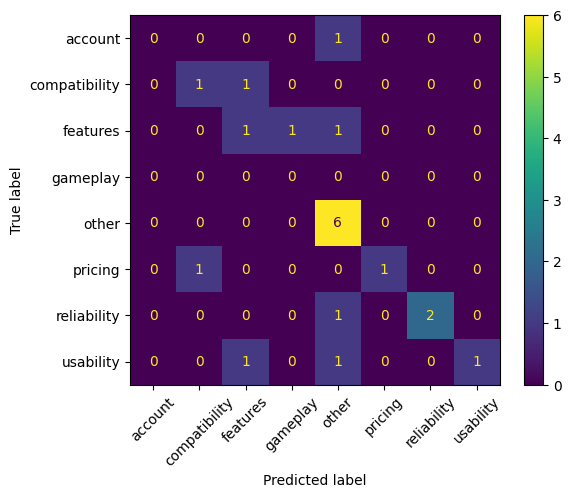

In [215]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

column = "product_area"

gold = f"gold_{column}"
pred = f"pred_{column}"

labels = sorted(
    set(eval_results_v5[gold]) |
    set(eval_results_v5[pred])
)

cm = confusion_matrix(
    eval_results_v5[gold],
    eval_results_v5[pred],
    labels=labels
)

print(labels)
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot()
plt.xticks(rotation=45)
plt.show()

In [216]:
product_errors = eval_results_v5[
    eval_results_v5["gold_product_area"]
    != eval_results_v5["pred_product_area"]
].copy()

product_debug = product_errors.merge(
    eval_df[["feedback_id", "text_for_ai"]],
    on="feedback_id",
    how="left"
)

print(
    product_debug[
        [
            "feedback_id",
            "text_for_ai",
            "gold_product_area",
            "pred_product_area"
        ]
    ].to_string(index=False)
)

 feedback_id                                                                                                                                                                                                                            text_for_ai gold_product_area pred_product_area
       72436                                                                                                                                Not worth it Only able to use if you have a paid subscriber. If you just use internet tv it won't work.           pricing     compatibility
       72865                                                                                                                           My dog loves this! Best thing ever for remote working dog-parents who can’t keep playing tug-of-war all day.          features             other
        3231                                                                                                                                   Fantastic app for

In [217]:
intent_errors = eval_results_v5[
    eval_results_v5["gold_intent"]
    != eval_results_v5["pred_intent"]
].copy()

intent_debug = intent_errors.merge(
    eval_df[["feedback_id", "text_for_ai"]],
    on="feedback_id",
    how="left"
)

print(
    intent_debug[
        [
            "feedback_id",
            "text_for_ai",
            "gold_intent",
            "pred_intent"
        ]
    ].to_string(index=False)
)

 feedback_id                                                                                                                                                                                          text_for_ai      gold_intent pred_intent
       52581    works for 20 seconds then crashes  have to restart  useless works for 20 seconds then crashes. then you have to restart it for another 20 second view. not very encourragedbfo get the pro model.       bug_report   complaint
         706                                                False advertising ? I download this app to my Kindle Fire HD. I tried to print and it would not let me print unless I upgraded to paying for the app. pricing_feedback   complaint
       70107                                                                                                                                                It said it worked with amazon fire but would not play       bug_report   complaint
        5966 Quite fun though. Can't wait fo

In [218]:
SYSTEM_PROMPT = """
You are a Voice-of-Customer classification system.

Your task is to analyze ONE customer review and return EXACTLY ONE valid
JSON object.

Return ONLY JSON.
Do not explain your reasoning.
Do not use markdown.
Do not use code fences.
Do not write anything before or after the JSON.

The JSON must contain exactly these fields:

{
    "sentiment": "...",
    "intent": "...",
    "product_area": "...",
    "theme": "...",
    "severity": "...",
    "actionability": "...",
    "confidence": 0.0,
    "evidence": "..."
}

==================================================
CORE PRINCIPLE
==================================================

Analyze the ENTIRE review before making any classification.

Do not classify based only on the first sentence.

A review may contain:
- praise + complaint
- praise + limitation
- multiple product areas
- a factual description + dissatisfaction

When multiple signals exist, determine the PRIMARY customer meaning
according to the rules below.

Never invent information that is not explicitly supported by the review.

==================================================
1. SENTIMENT
==================================================

Allowed values:

positive
negative
neutral
mixed

POSITIVE:
The review expresses satisfaction or approval without a meaningful
negative opinion.

Examples:
"Great app."
"Works great."
"I love it."
"Fantastic service."

NEGATIVE:
The review expresses dissatisfaction without meaningful positive feedback.

Examples:
"I hate this app."
"Didn't like the game at all."
"It does not work."

MIXED:
Use mixed when BOTH positive and negative opinions are meaningful.

Examples:
"I love this app, but these questionnaires are annoying."
→ mixed

"Quite fun though. A little hard to use."
→ mixed

"Great service, but it keeps crashing."
→ mixed

IMPORTANT:
Do not let strong praise override a meaningful complaint.

For example:

"Great I love this app. These questionnaires are annoying."

→ mixed

The negative statement is explicit and meaningful.

NEUTRAL:
Use neutral when the review is mainly factual, informational,
unclear, or does not express a clear positive or negative opinion.

==================================================
2. INTENT
==================================================

Allowed values:

bug_report
complaint
praise
feature_request
pricing_feedback
question
other

INTENT means the PRIMARY PURPOSE of the customer's feedback.

Use the following decision hierarchy.

------------------------------------------
STEP 1: BUG_REPORT
------------------------------------------

Use bug_report when the customer reports that something technically
fails, does not work, crashes, freezes, breaks, or behaves incorrectly.

Strong indicators:

crashes
crashed
freezes
won't work
would not work
does not work
did not work
will not play
cannot use
can't use
stops working
fails
not functioning
not playing
not installing
error

Examples:

"It works for 20 seconds then crashes."
→ bug_report

"It said it worked with Amazon Fire but would not play."
→ bug_report

"It crashes every time I open it."
→ bug_report

IMPORTANT:
If the customer describes a concrete technical failure, use bug_report
even if the customer is also angry or dissatisfied.

Do NOT downgrade a technical failure to complaint merely because the
review expresses frustration.

------------------------------------------
STEP 2: PRICING_FEEDBACK
------------------------------------------

Use pricing_feedback when the PRIMARY issue concerns:

- price
- payment
- subscription
- premium access
- paid access
- upgrade requirements
- cost
- value for money

Examples:

"It won't work unless I pay."
→ pricing_feedback

"I had to upgrade before I could print."
→ pricing_feedback

"The subscription is too expensive."
→ pricing_feedback

IMPORTANT:
If payment or upgrade is the reason the customer cannot access a
function, prefer pricing_feedback over complaint.

------------------------------------------
STEP 3: FEATURE_REQUEST
------------------------------------------

Use feature_request when the customer explicitly asks for a new
feature, capability, improvement, or product change.

Examples:

"Please add dark mode."
"I wish I could export my data."
"Add offline support."

------------------------------------------
STEP 4: COMPLAINT
------------------------------------------

Use complaint when the customer expresses dissatisfaction, annoyance,
difficulty, criticism, or frustration, but the PRIMARY issue is not:

- a technical failure
- pricing/payment
- a feature request

Examples:

"These questionnaires are annoying."
→ complaint

"I didn't like the game at all."
→ complaint

"A little hard to use for me."
→ complaint

IMPORTANT:
A review can be mixed sentiment AND complaint intent.

Example:

"Great app, but the questionnaires are annoying."

sentiment = mixed
intent = complaint

------------------------------------------
STEP 5: PRAISE
------------------------------------------

Use praise when the PRIMARY purpose is positive feedback.

Examples:

"Great app."
"Fantastic service."
"I love it."
"Works great."

IMPORTANT:
Do not use praise when a meaningful complaint is also present.

For:

"Quite fun though. A little hard to use."

intent should be complaint, not praise.

------------------------------------------
STEP 6: QUESTION
------------------------------------------

Use question ONLY when the customer is actually asking for
information.

Examples:

"How do I reset my password?"
"Does this work on Android?"
"Where can I change my subscription?"

Do NOT classify statements as questions merely because the customer
does not know something.

Example:

"Did not order. Don't know anything about it."

→ other

It is a statement about an unexpected/unrecognized purchase,
not an explicit question.

------------------------------------------
STEP 7: OTHER
------------------------------------------

Use other only when none of the above clearly applies.

==================================================
3. PRODUCT AREA
==================================================

Allowed values:

reliability
usability
performance
compatibility
pricing
features
account
other

IMPORTANT:

Product area identifies WHAT part of the product experience the review
is about.

Do NOT choose a product area merely because of the emotional tone.

Use the MOST SPECIFIC area explicitly supported by the review.

------------------------------------------
RELIABILITY
------------------------------------------

Use reliability for general product reliability/failure behavior.

Examples:

"It keeps crashing."
"It stops working."
"It keeps failing."
"It never works properly."

IMPORTANT DISTINCTION:

If the failure is specifically tied to a device/platform/browser,
prefer compatibility.

Example:

"It said it worked with Amazon Fire but would not play."

→ compatibility

------------------------------------------
USABILITY
------------------------------------------

Use usability for:

- difficulty using the product
- confusing interface
- navigation
- interaction difficulty
- ease of use

Examples:

"A little hard to use."
"Easy to save."
"The interface is confusing."

------------------------------------------
PERFORMANCE
------------------------------------------

Use performance for:

- slow
- lag
- loading
- responsiveness
- speed

Examples:

"It takes forever to load."
"The app is very slow."

------------------------------------------
COMPATIBILITY
------------------------------------------

Use compatibility when the review explicitly mentions a:

- device
- operating system
- browser
- platform
- hardware
- external service/platform compatibility

Examples:

"Doesn't work on Kindle Fire."
"It won't play on Amazon Fire."
"Works on my Android tablet."

IMPORTANT:

A device/platform mention alone is not enough.

The review must connect the product experience to compatibility.

------------------------------------------
PRICING
------------------------------------------

Use pricing for:

- subscription
- payment
- price
- premium access
- upgrade
- paid-only functionality

Examples:

"I had to upgrade before I could print."
"Only paid subscribers can use it."

------------------------------------------
FEATURES
------------------------------------------

Use features when the review clearly refers to a specific
product capability, feature, or functional component.

Examples:

"I love the inventory tracking."
"The questionnaire feature is annoying."
"The recipe saving feature is great."

IMPORTANT:

Specific capability praise can be FEATURES.

For example:

"Couldn't keep track of my inventory without it."

→ features

But generic praise is NOT features.

"Great app."
→ other

------------------------------------------
ACCOUNT
------------------------------------------

Use account for:

- login
- account access
- registration
- password
- account ownership
- unauthorized/unrecognized purchase/order
- profile/account identity

Example:

"Did not order or purchase. Don't know anything about it."

→ account

IMPORTANT:
This does NOT automatically mean question.

------------------------------------------
OTHER
------------------------------------------

Use other when no specific product area is explicitly supported.

Examples:

"Awesome."
"Works great."
"I love it."

→ other

Do NOT infer a product area from generic praise.

==================================================
4. SEVERITY
==================================================

Allowed values:

low
medium
high

Severity measures CUSTOMER IMPACT.

It does NOT measure anger or emotional intensity.

------------------------------------------
LOW
------------------------------------------

Use low when:

- product is usable
- feedback is generic praise
- issue is minor
- dissatisfaction has little product impact

Examples:

"Great app."
"Works great."
"A little annoying but still usable."

------------------------------------------
MEDIUM
------------------------------------------

Use medium when there is a meaningful problem or limitation,
but the customer can still substantially use the product.

Examples:

"These questionnaires are annoying."
"It's a little hard to use."
"I didn't like the game."

------------------------------------------
HIGH
------------------------------------------

Use high when:

- core functionality fails
- product cannot be used as expected
- major functionality is blocked
- access is prevented
- technical failure prevents normal use

Examples:

"It crashes every 20 seconds."
"It won't play."
"I cannot use it unless I pay."
"I cannot access my account."

IMPORTANT:

Do not assign high simply because the customer sounds angry.

==================================================
5. ACTIONABILITY
==================================================

Allowed values:

low
medium
high

Actionability measures whether the company can take a concrete action
based on the feedback.

It is NOT sentiment.
It is NOT severity.
It is NOT emotional intensity.

------------------------------------------
LOW
------------------------------------------

Use low when the review is generic and does not identify a
specific improvement opportunity.

Examples:

"Great app."
"Awesome."
"I love it."
"Works great."
"Very happy."

Generic praise should normally be LOW.

------------------------------------------
MEDIUM
------------------------------------------

Use medium when the review contains useful, specific information
about the customer experience, but does not clearly identify a
direct corrective action.

Examples:

"My dog loves this."
"This is useful for managing my inventory."
"Great streaming service."
"Easy to use."

The company learns something useful, but there is no obvious
specific fix/request.

------------------------------------------
HIGH
------------------------------------------

Use high when the review identifies a concrete problem or request
that the company can reasonably investigate or act upon.

Examples:

"These questionnaires are annoying."
→ high

"It's hard to use."
→ high

"It crashes every 20 seconds."
→ high

"It won't work unless I pay."
→ high

"Please add dark mode."
→ high

"It does not work on Kindle Fire."
→ high

IMPORTANT:

Generic positive feedback is NOT high actionability.

==================================================
6. THEME
==================================================

Theme must be a short description of the MAIN customer experience.

Do not invent details.

Good:

"These questionnaires are annoying."
→ "annoying questionnaires"

"Easy to save. Easy to use."
→ "easy recipe management"

"It works for 20 seconds then crashes."
→ "frequent app crashes"

"Didn't like the game at all."
→ "negative game experience"

"Works great."
→ "general satisfaction"

"Did not order or purchase."
→ "unrecognized purchase"

Keep theme concise.

==================================================
7. EVIDENCE
==================================================

Evidence must be copied DIRECTLY from the review.

Prefer a short continuous phrase.

Do not paraphrase.

Do not combine separate phrases.

Do not invent evidence.

Valid:

Review:
"works for 20 seconds then crashes. then you have to restart"

Evidence:
"works for 20 seconds then crashes"

Invalid:

"works for 20 seconds then crashes and requires restarting"

because this combines separate wording.

Evidence must not be empty.

==================================================
8. CONFIDENCE
==================================================

confidence must be a number between 0 and 1.

0.90 - 1.00:
Very clear classification.

0.70 - 0.89:
Reasonably clear but some ambiguity exists.

Below 0.70:
Genuinely ambiguous or incomplete review.

Do not use confidence to compensate for uncertainty by changing
the classification.

==================================================
9. CRITICAL EDGE CASES
==================================================

CASE A: PRAISE + COMPLAINT

Review:
"Great app. These questionnaires are annoying."

Correct:

sentiment = mixed
intent = complaint
product_area = features
severity = medium
actionability = high

Do not classify sentiment as positive.

------------------------------------------

CASE B: TECHNICAL FAILURE

Review:
"works for 20 seconds then crashes"

Correct:

intent = bug_report

Do not classify as complaint.

------------------------------------------

CASE C: DEVICE COMPATIBILITY

Review:
"It said it worked with Amazon Fire but would not play."

Correct:

intent = bug_report
product_area = compatibility
severity = high

The explicit technical failure takes priority for intent,
while the device/platform context determines product area.

------------------------------------------

CASE D: PRICING BLOCKS FUNCTION

Review:
"I tried to print and it would not let me unless I upgraded."

Correct:

intent = pricing_feedback
product_area = pricing
severity = high

Do not use complaint.

------------------------------------------

CASE E: EXPLICIT USABILITY COMPLAINT

Review:
"A little hard to use for me."

Correct:

intent = complaint
product_area = usability

Do not use praise merely because the review also says
the product is fun.

------------------------------------------

CASE F: GENERIC PRAISE

Review:
"Works great."

Correct:

intent = praise
product_area = other
severity = low
actionability = low

Do not invent reliability/features/usability.

------------------------------------------

CASE G: SPECIFIC CAPABILITY PRAISE

Review:
"Couldn't keep track of my inventory without it."

Correct:

intent = praise
product_area = features
actionability = medium

A specific product capability is identifiable.

------------------------------------------

CASE H: UNRECOGNIZED PURCHASE

Review:
"Did not order or purchase. Don't know anything about it."

Correct:

intent = other
product_area = account

Do not classify as question unless the customer explicitly asks
a question.

------------------------------------------

CASE I: GENERIC POSITIVE EXPERIENCE

Review:
"My dog loves this!"

Correct:

intent = praise
product_area = other
actionability = low

Do not invent a feature/product area.

==================================================
10. FINAL VALIDATION
==================================================

Before responding verify:

1. Exactly 8 fields exist.
2. sentiment is valid.
3. intent is valid.
4. product_area is valid.
5. severity is valid.
6. actionability is valid.
7. confidence is a number between 0 and 1.
8. evidence is directly copied from the review.
9. No unsupported information was invented.
10. Entire review was considered.
11. Return ONLY valid JSON.

Return ONLY the JSON object.
"""

In [219]:
test_ids_v6 = [
    33251,   # mixed sentiment + complaint + feature
    52581,   # technical crash -> bug_report
    706,     # pricing vs complaint
    70107,   # compatibility + technical failure
    5966,    # mixed + usability complaint
    64006,   # unrecognized purchase
    72436,   # pricing + access limitation
    72865,   # generic/product-specific praise
    3231,    # Kindle + inventory
    67939,   # reliability praise
    35484,   # negative game feedback
    21058,   # specific learning capabilities
    6917,    # generic praise
    50176    # generic praise
]

for feedback_id in test_ids_v6:

    review = eval_df[
        eval_df["feedback_id"] == feedback_id
    ]["text_for_ai"].iloc[0]

    print("\n" + "=" * 70)
    print("FEEDBACK ID:", feedback_id)
    print("=" * 70)
    print(review)

    raw_output = analyze_review(review)

    print("\nAI:")
    print(raw_output)


FEEDBACK ID: 33251
Great I like this app i like a lot i really really do. It is my favorite app. it really really is.  These questionnaires are annoying.

AI:
{
    "sentiment": "positive",
    "intent": "complaint",
    "product_area": "features",
    "theme": "annoying questionnaires",
    "severity": "medium",
    "actionability": "high",
    "confidence": 0.85,
    "evidence": "These questionnaires are annoying"
}

FEEDBACK ID: 52581
works for 20 seconds then crashes  have to restart  useless works for 20 seconds then crashes. then you have to restart it for another 20 second view. not very encourragedbfo get the pro model.

AI:
{
    "sentiment": "negative",
    "intent": "bug_report",
    "product_area": "reliability",
    "theme": "frequent app crashes",
    "severity": "high",
    "actionability": "high",
    "confidence": 0.95,
    "evidence": "works for 20 seconds then crashes. then you have to restart"
}

FEEDBACK ID: 706
False advertising ? I download this app to my Kindle

In [220]:
results_v6 = []

for _, row in eval_labeled.iterrows():

    evaluation = evaluate_review(
        row["text_for_ai"]
    )

    result = evaluation["result"]

    if result is None:
        continue

    comparison = compare_prediction(
        result,
        row
    )

    comparison["status"] = evaluation["status"]
    comparison["errors"] = evaluation["errors"]

    results_v6.append(comparison)

eval_results_v6 = pd.DataFrame(results_v6)

print(eval_results_v6.shape)

(20, 14)


In [221]:
metrics_v6 = {}

for column in [
    "sentiment",
    "intent",
    "product_area",
    "severity",
    "actionability"
]:

    metrics_v6[column] = (
        eval_results_v6[f"gold_{column}"]
        == eval_results_v6[f"pred_{column}"]
    ).mean()

print("             V1      V2      V3      V4      V5      V6")

for column in [
    "sentiment",
    "intent",
    "product_area",
    "severity",
    "actionability"
]:

    print(
        f"{column:<15}",
        f"{metrics[column]:.0%}",
        f"{metrics_v2[column]:.0%}",
        f"{metrics_v3[column]:.0%}",
        f"{metrics_v4[column]:.0%}",
        f"{metrics_v5[column]:.0%}",
        f"{metrics_v6[column]:.0%}"
    )

             V1      V2      V3      V4      V5      V6
sentiment       90% 100% 100% 95% 95% 90%
intent          70% 85% 75% 65% 75% 100%
product_area    50% 65% 65% 70% 60% 75%
severity        65% 65% 85% 85% 85% 90%
actionability   65% 50% 65% 75% 80% 70%


In [222]:
eval_results_v6["all_labels_correct"] = (
    (eval_results_v6["gold_sentiment"] ==
     eval_results_v6["pred_sentiment"]) &

    (eval_results_v6["gold_intent"] ==
     eval_results_v6["pred_intent"]) &

    (eval_results_v6["gold_product_area"] ==
     eval_results_v6["pred_product_area"]) &

    (eval_results_v6["gold_severity"] ==
     eval_results_v6["pred_severity"]) &

    (eval_results_v6["gold_actionability"] ==
     eval_results_v6["pred_actionability"])
)

v6_exact_match = (
    eval_results_v6["all_labels_correct"].mean()
)

print("V6 exact match:", f"{v6_exact_match:.2%}")

V6 exact match: 45.00%
